# AUR–QAUR Practical Portfolio Optimization — Standalone Full Web Colab ngày 30/8

Notebook chứa **toàn bộ code và bộ dữ liệu nén đã khóa SHA-256**. Không clone
GitHub, không mount Drive và không cần upload thêm tệp; chỉ chọn
**Runtime → Run all**.

Notebook tách hai lớp bằng chứng:

1. **Confirmatory historical:** chọn cấu hình trên folds 0–28 và kiểm định trên
   untouched historical holdout folds 29–43.
2. **Practical method design:** chạy grid ràng buộc, allocation và common market
   gate trên toàn bộ dữ liệu đã quan sát đến 29/8/2026, sau đó tạo rổ paper
   trading. Lớp này là post-hoc và không được gọi là prospective proof.

Đối tượng so sánh là AUR và QAUR. Cả hai dùng chung portfolio QUBO, shared
fixed-cardinality solver, weight allocation, transaction cost, market gate và
walk-forward backtest. QAUR hiện là classical cardinality-preserving surrogate;
notebook không tuyên bố quantum advantage hoặc cho phép dùng vốn thật.


# Kết quả đã xác minh — hiển thị sẵn, không cần kết nối runtime

Các bảng dưới đây được nhúng từ lần chạy end-to-end đã vượt qua
`RESEARCH_AUDIT_29_8_OK`. Phần mã nguồn đầy đủ và dữ liệu standalone nằm phía
dưới; chọn **Runtime → Run all** để tái tạo độc lập toàn bộ artifacts.

- Dữ liệu quan sát đến: **2026-08-28**.
- SHA-256 dữ liệu: `b0a16d9f8c31a2a5d4e1ba8f00d49b50f112f149d4fae23b3529df085a45ccb2`.
- Confirmatory split: development **0–28**, untouched holdout **29–43**.
- Cấu hình thực tiễn: **C1_IV_X**, `K=8`,
  `k_p=4`, inverse-volatility,
  weight bounds **5%–30%**,
  transaction cost **25 bps**.
- Common market gate: **30 phiên**.
- XY-QAOA audit: **30 instances**,
  feasibility trung bình **100%**.
- Không cho phép vốn thật; không tuyên bố quantum advantage.


## H1–H5 — kiểm định xác nhận trên historical holdout

| hypothesis                                      |   estimate |   statistic |   pvalue_one_sided | supported_5pct   | evidence_label                            |   holm_adjusted_pvalue | supported_holm_5pct   |
|:------------------------------------------------|-----------:|------------:|-------------------:|:-----------------|:------------------------------------------|-----------------------:|:----------------------|
| H1_QAUR_higher_QUR_objective                    |   0.060278 |    5.088779 |           0.000083 | True             | confirmatory_untouched_historical_holdout |               0.000248 | True                  |
| H2_QAUR_lower_candidate_correlation             |  -0.012364 |   -6.906410 |           0.000004 | True             | confirmatory_untouched_historical_holdout |               0.000014 | True                  |
| H3_QAUR_turnover_noninferior_margin_2pp         |  -0.060000 |   -2.386402 |           0.015841 | True             | confirmatory_untouched_historical_holdout |               0.031683 | True                  |
| H4_QAUR_higher_mean_daily_return                |  -0.000036 |   -0.170742 |           0.567731 | False            | confirmatory_untouched_historical_holdout |               0.567731 | False                 |
| H5_QAUR_financial_direction_robust_across_seeds |   0.000000 |  nan        |         nan        | False            | confirmatory_untouched_historical_holdout |             nan        | False                 |

**Kết luận:** H1, H2 và H3 được ủng hộ sau Holm 5%; H4 và H5 chưa được ủng hộ.


## Hiệu quả đầu tư của cấu hình thực tiễn được chọn

| config_id   |   market_gate_lookback | sample                       | method   |   observations |   cumulative_return |   annualized_return |   annualized_volatility |   sharpe_zero_rf |   sortino_zero_rf |   maximum_drawdown |
|:------------|-----------------------:|:-----------------------------|:---------|---------------:|--------------------:|--------------------:|------------------------:|-----------------:|------------------:|-------------------:|
| C1_IV_X     |                     30 | development_2022_2024        | AUR      |            604 |            0.236253 |            0.092519 |                0.094271 |         0.981416 |          0.965711 |          -0.157677 |
| C1_IV_X     |                     30 | development_2022_2024        | QAUR     |            604 |            0.236253 |            0.092519 |                0.094271 |         0.981416 |          0.965711 |          -0.157677 |
| C1_IV_X     |                     30 | historical_holdout_2024_2025 | AUR      |            312 |            0.144300 |            0.115019 |                0.131991 |         0.871415 |          0.984565 |          -0.130961 |
| C1_IV_X     |                     30 | historical_holdout_2024_2025 | QAUR     |            312 |            0.195703 |            0.155302 |                0.136360 |         1.138915 |          1.327011 |          -0.130961 |
| C1_IV_X     |                     30 | observed_2026                | AUR      |            160 |            0.088069 |            0.142178 |                0.123103 |         1.154950 |          1.400847 |          -0.077845 |
| C1_IV_X     |                     30 | observed_2026                | QAUR     |            160 |            0.088005 |            0.142073 |                0.123112 |         1.154014 |          1.399627 |          -0.077845 |


## Lợi nhuận dương và bằng chứng thống kê

| sample                       | method   |   observations |   mean_daily_return |   cumulative_return |   one_sample_t_pvalue |   block_bootstrap_ci_low |   block_bootstrap_ci_high |   block_bootstrap_pvalue |   combined_conservative_pvalue |   holm_adjusted_pvalue | positive_economically   | positive_mean_supported_holm_5pct   | evidence_label                         |
|:-----------------------------|:---------|---------------:|--------------------:|--------------------:|----------------------:|-------------------------:|--------------------------:|-------------------------:|-------------------------------:|-----------------------:|:------------------------|:------------------------------------|:---------------------------------------|
| development_2022_2024        | AUR      |            604 |            0.000369 |            0.236253 |              0.063710 |                -0.000054 |                  0.001065 |                 0.036993 |                       0.063710 |               0.382262 | True                    | False                               | posthoc_method_design_not_confirmatory |
| development_2022_2024        | QAUR     |            604 |            0.000369 |            0.236253 |              0.063710 |                -0.000054 |                  0.001065 |                 0.036993 |                       0.063710 |               0.382262 | True                    | False                               | posthoc_method_design_not_confirmatory |
| historical_holdout_2024_2025 | AUR      |            312 |            0.000467 |            0.144300 |              0.161187 |                -0.000391 |                  0.001418 |                 0.132573 |                       0.161187 |               0.483562 | True                    | False                               | posthoc_method_design_not_confirmatory |
| historical_holdout_2024_2025 | QAUR     |            312 |            0.000610 |            0.195703 |              0.105419 |                -0.000293 |                  0.001668 |                 0.085183 |                       0.105419 |               0.421675 | True                    | False                               | posthoc_method_design_not_confirmatory |
| observed_2026                | AUR      |            160 |            0.000558 |            0.088069 |              0.182261 |                -0.000573 |                  0.001174 |                 0.192961 |                       0.192961 |               0.483562 | True                    | False                               | posthoc_method_design_not_confirmatory |
| observed_2026                | QAUR     |            160 |            0.000557 |            0.088005 |              0.182433 |                -0.000573 |                  0.001174 |                 0.192961 |                       0.192961 |               0.483562 | True                    | False                               | posthoc_method_design_not_confirmatory |

Lợi nhuận tích lũy dương ở 6/6 ô period × reducer, nhưng mean daily return không đạt ý nghĩa sau hiệu chỉnh Holm; đây là hiệu quả kinh tế hậu nghiệm, chưa phải prospective proof.


## H4 theo từng giai đoạn

| sample                       |   observations |   mean_daily_difference |   paired_t_statistic |   paired_t_pvalue_one_sided |   block_bootstrap_ci_low |   block_bootstrap_ci_high |   block_bootstrap_pvalue_one_sided | supported_5pct   | evidence_label                         |
|:-----------------------------|---------------:|------------------------:|---------------------:|----------------------------:|-------------------------:|--------------------------:|-----------------------------------:|:-----------------|:---------------------------------------|
| development_2022_2024        |            604 |                0.000000 |           nan        |                  nan        |                 0.000000 |                  0.000000 |                           1.000000 | False            | posthoc_method_design_not_confirmatory |
| historical_holdout_2024_2025 |            312 |                0.000143 |             0.962903 |                    0.168172 |                -0.000067 |                  0.000384 |                           0.085983 | False            | posthoc_method_design_not_confirmatory |
| observed_2026                |            160 |               -0.000000 |            -1.000000 |                    0.840585 |                -0.000000 |                  0.000000 |                           1.000000 | False            | posthoc_method_design_not_confirmatory |


## Rổ cổ phiếu tháng 9/2026 — shadow và executable

| config_id   |   fold | method   | ticker   | selected_downstream   |   weight |   shadow_weight |   executable_weight |   cash_weight |   market_growth |   market_gate_exposure |
|:------------|-------:|:---------|:---------|:----------------------|---------:|----------------:|--------------------:|--------------:|----------------:|-----------------------:|
| C1_IV_X     |     53 | AUR      | NAF      | True                  | 0.300000 |        0.300000 |            0.000000 |      1.000000 |       -0.011352 |               0.000000 |
| C1_IV_X     |     53 | AUR      | STB      | True                  | 0.210668 |        0.210668 |            0.000000 |      1.000000 |       -0.011352 |               0.000000 |
| C1_IV_X     |     53 | AUR      | VCB      | True                  | 0.246890 |        0.246890 |            0.000000 |      1.000000 |       -0.011352 |               0.000000 |
| C1_IV_X     |     53 | AUR      | VJC      | True                  | 0.242442 |        0.242442 |            0.000000 |      1.000000 |       -0.011352 |               0.000000 |
| C1_IV_X     |     53 | QAUR     | NAF      | True                  | 0.300000 |        0.300000 |            0.000000 |      1.000000 |       -0.011352 |               0.000000 |
| C1_IV_X     |     53 | QAUR     | STB      | True                  | 0.210668 |        0.210668 |            0.000000 |      1.000000 |       -0.011352 |               0.000000 |
| C1_IV_X     |     53 | QAUR     | VCB      | True                  | 0.246890 |        0.246890 |            0.000000 |      1.000000 |       -0.011352 |               0.000000 |
| C1_IV_X     |     53 | QAUR     | VJC      | True                  | 0.242442 |        0.242442 |            0.000000 |      1.000000 |       -0.011352 |               0.000000 |

Market gate 30 phiên đang âm nên `executable_weight = 0` và cash = 100%; shadow basket chỉ dùng cho paper trading.


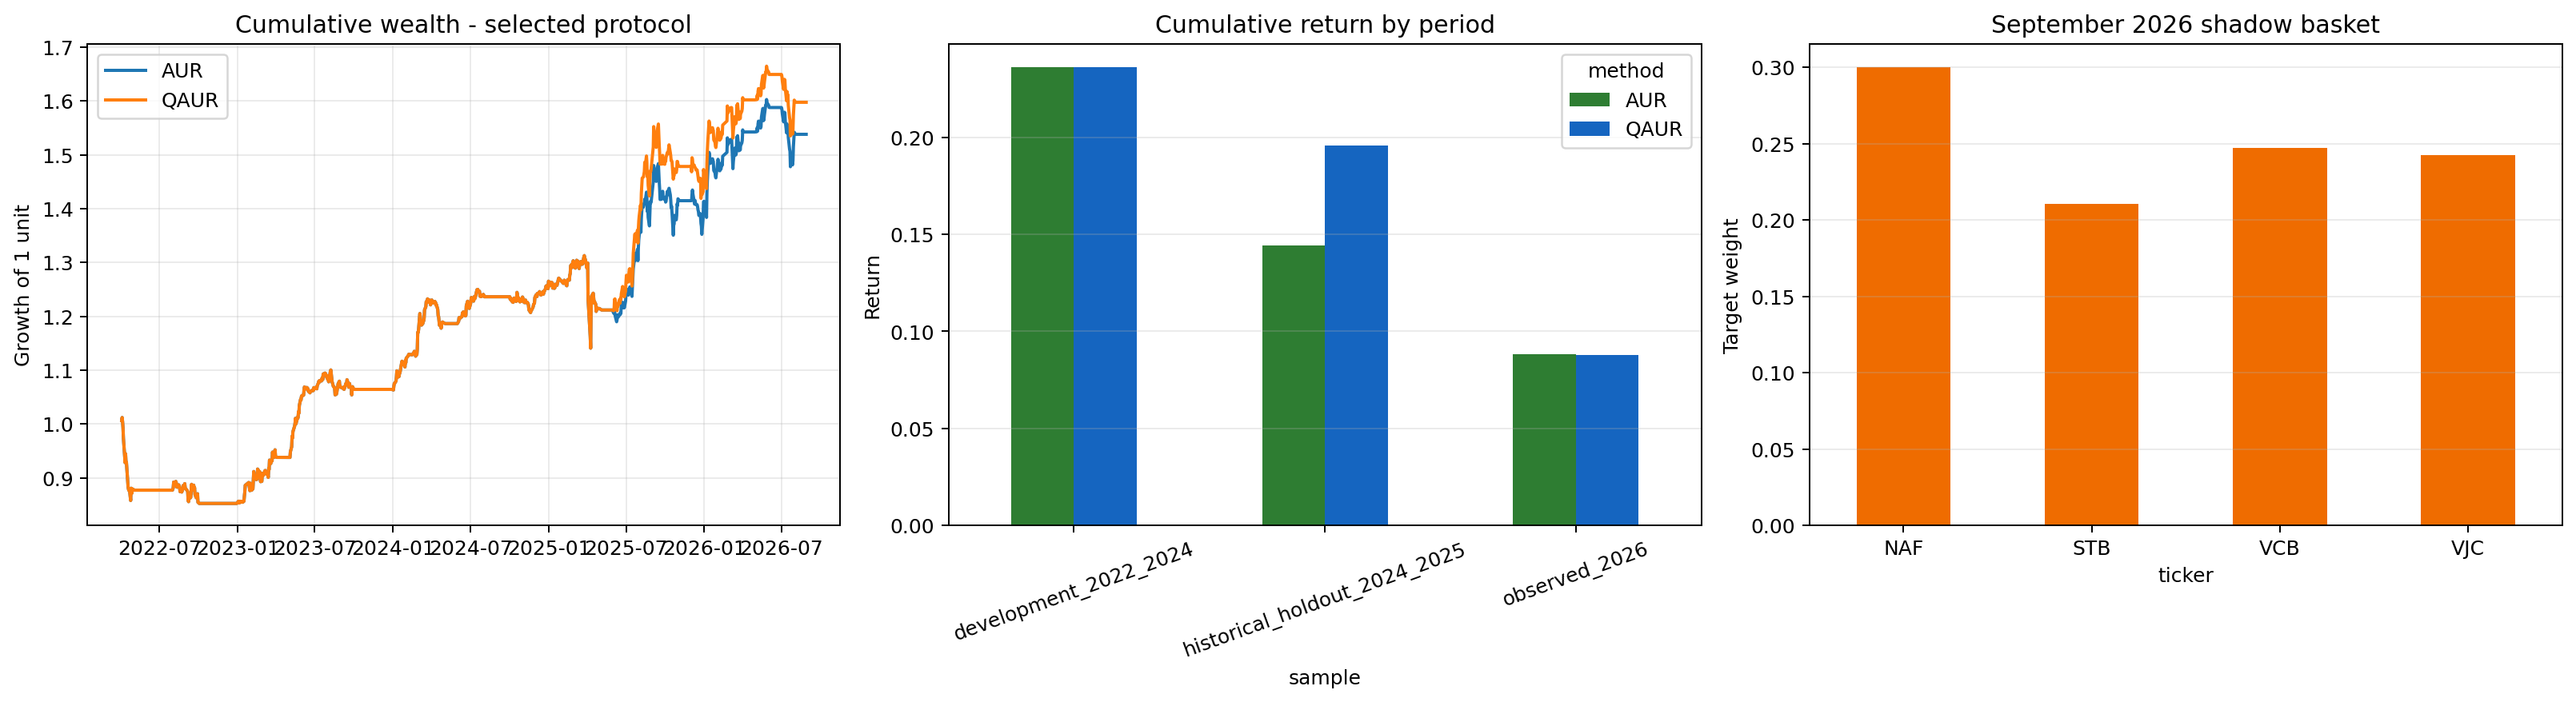

In [1]:
# Precomputed figure from the audited web-equivalent release.


## Chẩn đoán dự báo XGBoost/EWMA

### Tổng hợp

|   walk_forward_folds |   mean_validation_rank_ic |   median_validation_rank_ic |   positive_rank_ic_folds |   mean_validation_rmse |   mean_universe_size |
|---------------------:|--------------------------:|----------------------------:|-------------------------:|-----------------------:|---------------------:|
|            54.000000 |                  0.074216 |                    0.093523 |                40.000000 |               0.287510 |            97.796296 |

### Toàn bộ 54 folds

|   fold | decision_time   |   validation_rank_ic |   validation_rmse |   train_rows |   universe_size |   runtime_seconds |
|-------:|:----------------|---------------------:|------------------:|-------------:|----------------:|------------------:|
|      0 | 2022-04-01      |             0.145810 |          0.282548 |        52345 |             110 |          0.506831 |
|      1 | 2022-04-29      |             0.165189 |          0.282885 |        52738 |             110 |          0.375969 |
|      2 | 2022-06-01      |             0.076492 |          0.286958 |        52551 |             106 |          0.402733 |
|      3 | 2022-07-01      |            -0.183707 |          0.294817 |        52679 |             107 |          0.369869 |
|      4 | 2022-08-01      |            -0.083311 |          0.300197 |        52778 |             103 |          0.395962 |
|      5 | 2022-08-31      |            -0.217702 |          0.306790 |        52813 |             101 |          0.501389 |
|      6 | 2022-09-30      |            -0.070165 |          0.306097 |        52841 |             103 |          0.367672 |
|      7 | 2022-11-01      |             0.246388 |          0.282893 |        52758 |             103 |          0.388388 |
|      8 | 2022-12-01      |             0.037968 |          0.290867 |        52741 |             104 |          0.313469 |
|      9 | 2022-12-30      |             0.150262 |          0.282491 |        52577 |             101 |          0.315043 |
|     10 | 2023-02-01      |             0.165091 |          0.281152 |        52626 |             102 |          0.380331 |
|     11 | 2023-03-01      |             0.038802 |          0.290717 |        52548 |              97 |          0.339847 |
|     12 | 2023-03-31      |             0.085766 |          0.287186 |        52237 |             100 |          0.360734 |
|     13 | 2023-04-28      |            -0.011812 |          0.291622 |        51642 |              95 |          0.349405 |
|     14 | 2023-06-01      |            -0.082966 |          0.293135 |        52072 |              94 |          0.339733 |
|     15 | 2023-06-30      |            -0.116342 |          0.295054 |        51772 |              96 |          0.316599 |
|     16 | 2023-08-01      |            -0.097219 |          0.290352 |        51765 |              95 |          0.368132 |
|     17 | 2023-08-31      |            -0.043825 |          0.289720 |        51609 |              94 |          0.342508 |
|     18 | 2023-09-29      |             0.014266 |          0.287772 |        51342 |              92 |          0.322828 |
|     19 | 2023-11-01      |             0.249409 |          0.283338 |        51320 |              96 |          0.329228 |
|     20 | 2023-12-01      |             0.102939 |          0.284453 |        51046 |              96 |          0.326211 |
|     21 | 2023-12-29      |            -0.131077 |          0.291072 |        50769 |              95 |          0.343152 |
|     22 | 2024-02-01      |             0.002280 |          0.286917 |        50741 |              95 |          0.368435 |
|     23 | 2024-03-01      |             0.206982 |          0.281006 |        50473 |              94 |          0.341863 |
|     24 | 2024-04-01      |             0.223091 |          0.282177 |        50018 |              95 |          0.387111 |
|     25 | 2024-04-26      |             0.129455 |          0.285491 |        50211 |              92 |          0.313648 |
|     26 | 2024-05-31      |             0.016892 |          0.288808 |        49958 |              90 |          0.348205 |
|     27 | 2024-07-01      |             0.003928 |          0.288701 |        49548 |              91 |          0.319226 |
|     28 | 2024-08-01      |             0.136466 |          0.284339 |        49309 |              95 |          0.383058 |
|     29 | 2024-08-30      |             0.175133 |          0.282438 |        49276 |              96 |          0.348519 |
|     30 | 2024-10-01      |             0.202816 |          0.281833 |        49095 |              95 |          0.353553 |
|     31 | 2024-11-01      |             0.182354 |          0.281713 |        49212 |              90 |          0.338324 |
|     32 | 2024-11-29      |            -0.016113 |          0.289846 |        49022 |              95 |          0.376124 |
|     33 | 2024-12-31      |            -0.050224 |          0.290691 |        48910 |              93 |          0.358565 |
|     34 | 2025-01-24      |             0.065071 |          0.286125 |        48861 |              94 |          0.333198 |
|     35 | 2025-02-28      |             0.056167 |          0.287032 |        48582 |              96 |          0.310031 |
|     36 | 2025-04-01      |             0.059975 |          0.287062 |        48676 |              94 |          0.343278 |
|     37 | 2025-04-29      |             0.125900 |          0.285987 |        48606 |              93 |          0.412108 |
|     38 | 2025-05-30      |             0.218637 |          0.282870 |        48582 |              94 |          0.336737 |
|     39 | 2025-07-01      |             0.148329 |          0.285100 |        48550 |              92 |          0.338676 |
|     40 | 2025-08-01      |            -0.048388 |          0.290767 |        48439 |              95 |          0.319295 |
|     41 | 2025-08-29      |            -0.079196 |          0.292054 |        48322 |              95 |          0.385115 |
|     42 | 2025-10-01      |             0.071535 |          0.288117 |        48366 |              97 |          0.363608 |
|     43 | 2025-10-31      |             0.200113 |          0.282822 |        48470 |              97 |          0.339231 |
|     44 | 2025-12-01      |             0.172360 |          0.284697 |        48299 |              94 |          0.651393 |
|     45 | 2025-12-31      |             0.129427 |          0.285334 |        48535 |              94 |          0.468219 |
|     46 | 2026-01-28      |             0.144624 |          0.285220 |        48441 |             100 |          0.465110 |
|     47 | 2026-02-27      |             0.137232 |          0.286781 |        48323 |             100 |          0.396281 |
|     48 | 2026-04-01      |             0.101281 |          0.287404 |        48523 |             102 |          0.425449 |
|     49 | 2026-04-29      |             0.230350 |          0.281991 |        48105 |             104 |          0.407444 |
|     50 | 2026-06-01      |             0.220043 |          0.282945 |        48029 |             104 |          0.383073 |
|     51 | 2026-07-01      |             0.071693 |          0.287908 |        48273 |             105 |          0.368855 |
|     52 | 2026-07-31      |             0.126802 |          0.286075 |        48419 |             105 |          0.576422 |
|     53 | 2026-08-28      |             0.202371 |          0.283156 |        48379 |             105 |          0.355359 |


## QAUR seed robustness

### Confirmatory

|   qa_seed |   aur_sharpe |   qaur_sharpe |   qaur_minus_aur_sharpe |   mean_qaur_objective_advantage |
|----------:|-------------:|--------------:|------------------------:|--------------------------------:|
|  7.000000 |     1.373502 |      1.361758 |               -0.011744 |                        0.049357 |
| 42.000000 |     1.373502 |      1.338190 |               -0.035312 |                        0.049309 |
| 99.000000 |     1.373502 |      1.361758 |               -0.011744 |                        0.049357 |

### Practical

|         qa_seed |   aur_sharpe |   qaur_sharpe |   qaur_minus_aur_sharpe |   mean_qaur_objective_advantage |
|----------------:|-------------:|--------------:|------------------------:|--------------------------------:|
|        7.000000 |     1.154950 |      1.154014 |               -0.000937 |                       -0.003117 |
|       29.000000 |     1.154950 |      1.154014 |               -0.000937 |                       -0.003117 |
|      101.000000 |     1.154950 |      1.154014 |               -0.000937 |                       -0.003117 |
|     1009.000000 |     1.154950 |      1.154014 |               -0.000937 |                       -0.003117 |
| 20260829.000000 |     1.154950 |      1.154014 |               -0.000937 |                       -0.003117 |


## Toàn bộ 30 XY-QAOA holdout audit instances

|   fold | method   |   candidate_size |   portfolio_cardinality |   depth |   budget |   shots |   feasibility_rate |   optimality_gap |   success_probability |
|-------:|:---------|-----------------:|------------------------:|--------:|---------:|--------:|-------------------:|-----------------:|----------------------:|
|     29 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.011682 |
|     29 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.011682 |
|     30 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.013122 |
|     30 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.013122 |
|     31 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.020327 |
|     31 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.018263 |
|     32 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.065346 |
|     32 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.022053 |
|     33 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.040727 |
|     33 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.040727 |
|     34 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.030551 |
|     34 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.030225 |
|     35 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.029250 |
|     35 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.008500 |
|     36 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.015173 |
|     36 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.016001 |
|     37 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.131999 |
|     37 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.169804 |
|     38 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.056288 |
|     38 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.063624 |
|     39 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.027907 |
|     39 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.061820 |
|     40 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.042139 |
|     40 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.042493 |
|     41 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.010843 |
|     41 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.029722 |
|     42 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.020836 |
|     42 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.022277 |
|     43 | AUR      |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.070196 |
|     43 | QAUR     |               10 |                       6 |       2 |       30 |    1024 |           1.000000 |         0.000000 |              0.030352 |


## Toàn bộ 172 kết quả confirmatory (43 cấu hình × 2 mẫu × 2 reducers)

| config_id                  | sample      | method   |   observations |   cumulative_return |   annualized_return |   annualized_volatility |   sharpe_zero_rf |   sortino_zero_rf |   maximum_drawdown |
|:---------------------------|:------------|:---------|---------------:|--------------------:|--------------------:|------------------------:|-----------------:|------------------:|-------------------:|
| B00_current                | development | AUR      |            604 |           -0.277794 |           -0.126967 |                0.205378 |        -0.618209 |         -0.710648 |          -0.575614 |
| B00_current                | development | QAUR     |            604 |           -0.277794 |           -0.126967 |                0.205378 |        -0.618209 |         -0.710648 |          -0.575614 |
| B00_current                | holdout     | AUR      |            312 |            0.159731 |            0.127148 |                0.145479 |         0.873994 |          1.152399 |          -0.132172 |
| B00_current                | holdout     | QAUR     |            312 |            0.247297 |            0.195403 |                0.152800 |         1.278810 |          1.757926 |          -0.132172 |
| C1_EW_X                    | development | AUR      |            604 |           -0.230225 |           -0.103420 |                0.172125 |        -0.600842 |         -0.710357 |          -0.531847 |
| C1_EW_X                    | development | QAUR     |            604 |           -0.230225 |           -0.103420 |                0.172125 |        -0.600842 |         -0.710357 |          -0.531847 |
| C1_EW_X                    | holdout     | AUR      |            312 |            0.187463 |            0.148868 |                0.143285 |         1.038963 |          1.381897 |          -0.127371 |
| C1_EW_X                    | holdout     | QAUR     |            312 |            0.236500 |            0.187038 |                0.144743 |         1.292206 |          1.742916 |          -0.127371 |
| C1_EW_M                    | development | AUR      |            604 |           -0.096759 |           -0.041570 |                0.182595 |        -0.227661 |         -0.243649 |          -0.446351 |
| C1_EW_M                    | development | QAUR     |            604 |           -0.133707 |           -0.058127 |                0.182545 |        -0.318424 |         -0.339240 |          -0.461684 |
| C1_EW_M                    | holdout     | AUR      |            312 |            0.261969 |            0.206747 |                0.149316 |         1.384626 |          1.972340 |          -0.138641 |
| C1_EW_M                    | holdout     | QAUR     |            312 |            0.261969 |            0.206747 |                0.149316 |         1.384626 |          1.972340 |          -0.138641 |
| C1_IV_X                    | development | AUR      |            604 |           -0.157747 |           -0.069121 |                0.162381 |        -0.425673 |         -0.502889 |          -0.487182 |
| C1_IV_X                    | development | QAUR     |            604 |           -0.157747 |           -0.069121 |                0.162381 |        -0.425673 |         -0.502889 |          -0.487182 |
| C1_IV_X                    | holdout     | AUR      |            312 |            0.185274 |            0.147157 |                0.138140 |         1.065272 |          1.367102 |          -0.130961 |
| C1_IV_X                    | holdout     | QAUR     |            312 |            0.248558 |            0.196379 |                0.141556 |         1.387285 |          1.817633 |          -0.130961 |
| C1_IV_M                    | development | AUR      |            604 |           -0.099310 |           -0.042700 |                0.179507 |        -0.237875 |         -0.253152 |          -0.460334 |
| C1_IV_M                    | development | QAUR     |            604 |           -0.135119 |           -0.058767 |                0.179786 |        -0.326875 |         -0.347507 |          -0.475709 |
| C1_IV_M                    | holdout     | AUR      |            312 |            0.259202 |            0.204609 |                0.145894 |         1.402453 |          1.984241 |          -0.143633 |
| C1_IV_M                    | holdout     | QAUR     |            312 |            0.259202 |            0.204609 |                0.145894 |         1.402453 |          1.984241 |          -0.143633 |
| C1_NMV_X                   | development | AUR      |            604 |           -0.161615 |           -0.070907 |                0.183907 |        -0.385557 |         -0.442626 |          -0.519909 |
| C1_NMV_X                   | development | QAUR     |            604 |           -0.161615 |           -0.070907 |                0.183907 |        -0.385557 |         -0.442626 |          -0.519909 |
| C1_NMV_X                   | holdout     | AUR      |            312 |            0.148530 |            0.118347 |                0.141587 |         0.835860 |          1.122910 |          -0.120048 |
| C1_NMV_X                   | holdout     | QAUR     |            312 |            0.235466 |            0.186236 |                0.145541 |         1.279612 |          1.783686 |          -0.120048 |
| C1_NMV_M                   | development | AUR      |            604 |           -0.088594 |           -0.037964 |                0.194965 |        -0.194724 |         -0.212165 |          -0.472919 |
| C1_NMV_M                   | development | QAUR     |            604 |           -0.162595 |           -0.071360 |                0.193331 |        -0.369108 |         -0.400286 |          -0.503411 |
| C1_NMV_M                   | holdout     | AUR      |            312 |            0.309895 |            0.243630 |                0.158444 |         1.537639 |          2.288087 |          -0.137934 |
| C1_NMV_M                   | holdout     | QAUR     |            312 |            0.309895 |            0.243630 |                0.158444 |         1.537639 |          2.288087 |          -0.137934 |
| C1_NMVT_X                  | development | AUR      |            604 |           -0.286548 |           -0.131397 |                0.185936 |        -0.706681 |         -0.800192 |          -0.583420 |
| C1_NMVT_X                  | development | QAUR     |            604 |           -0.286548 |           -0.131397 |                0.185936 |        -0.706681 |         -0.800192 |          -0.583420 |
| C1_NMVT_X                  | holdout     | AUR      |            312 |            0.125513 |            0.100209 |                0.139746 |         0.717082 |          0.962530 |          -0.120771 |
| C1_NMVT_X                  | holdout     | QAUR     |            312 |            0.211062 |            0.167274 |                0.143877 |         1.162623 |          1.620012 |          -0.120771 |
| C1_NMVT_M                  | development | AUR      |            604 |           -0.093962 |           -0.040333 |                0.193849 |        -0.208063 |         -0.226484 |          -0.472259 |
| C1_NMVT_M                  | development | QAUR     |            604 |           -0.134280 |           -0.058386 |                0.190519 |        -0.306460 |         -0.331441 |          -0.475761 |
| C1_NMVT_M                  | holdout     | AUR      |            312 |            0.236224 |            0.186824 |                0.149652 |         1.248389 |          1.783262 |          -0.137666 |
| C1_NMVT_M                  | holdout     | QAUR     |            312 |            0.236224 |            0.186824 |                0.149652 |         1.248389 |          1.783262 |          -0.137666 |
| C2_EW_X                    | development | AUR      |            604 |           -0.208214 |           -0.092812 |                0.152447 |        -0.608814 |         -0.682601 |          -0.435518 |
| C2_EW_X                    | development | QAUR     |            604 |           -0.209874 |           -0.093606 |                0.152596 |        -0.613422 |         -0.682626 |          -0.436701 |
| C2_EW_X                    | holdout     | AUR      |            312 |            0.156333 |            0.124480 |                0.125899 |         0.988729 |          1.403065 |          -0.113050 |
| C2_EW_X                    | holdout     | QAUR     |            312 |            0.161370 |            0.128434 |                0.126997 |         1.011319 |          1.418902 |          -0.113050 |
| C2_EW_M                    | development | AUR      |            604 |           -0.290748 |           -0.133534 |                0.160832 |        -0.830274 |         -0.913074 |          -0.478358 |
| C2_EW_M                    | development | QAUR     |            604 |           -0.287092 |           -0.131674 |                0.160758 |        -0.819079 |         -0.900119 |          -0.478358 |
| C2_EW_M                    | holdout     | AUR      |            312 |            0.200387 |            0.158957 |                0.139902 |         1.136199 |          1.510366 |          -0.136232 |
| C2_EW_M                    | holdout     | QAUR     |            312 |            0.207653 |            0.164619 |                0.139038 |         1.183984 |          1.525520 |          -0.136232 |
| C2_IV_X                    | development | AUR      |            604 |           -0.144117 |           -0.062865 |                0.137669 |        -0.456639 |         -0.530088 |          -0.407337 |
| C2_IV_X                    | development | QAUR     |            604 |           -0.143218 |           -0.062455 |                0.138495 |        -0.450952 |         -0.522655 |          -0.406715 |
| C2_IV_X                    | holdout     | AUR      |            312 |            0.150456 |            0.119861 |                0.119167 |         1.005827 |          1.398451 |          -0.114202 |
| C2_IV_X                    | holdout     | QAUR     |            312 |            0.146269 |            0.116568 |                0.120271 |         0.969214 |          1.316555 |          -0.114202 |
| C2_IV_M                    | development | AUR      |            604 |           -0.195289 |           -0.086663 |                0.146667 |        -0.590883 |         -0.643972 |          -0.423787 |
| C2_IV_M                    | development | QAUR     |            604 |           -0.191958 |           -0.085087 |                0.146637 |        -0.580258 |         -0.632343 |          -0.423787 |
| C2_IV_M                    | holdout     | AUR      |            312 |            0.206197 |            0.163485 |                0.134687 |         1.213812 |          1.549514 |          -0.133752 |
| C2_IV_M                    | holdout     | QAUR     |            312 |            0.201180 |            0.159575 |                0.131327 |         1.215102 |          1.505423 |          -0.133752 |
| C2_NMV_X                   | development | AUR      |            604 |           -0.229933 |           -0.103279 |                0.185103 |        -0.557952 |         -0.603673 |          -0.507655 |
| C2_NMV_X                   | development | QAUR     |            604 |           -0.206196 |           -0.091848 |                0.184899 |        -0.496746 |         -0.534786 |          -0.492478 |
| C2_NMV_X                   | holdout     | AUR      |            312 |            0.197377 |            0.156609 |                0.131627 |         1.189796 |          1.602051 |          -0.120280 |
| C2_NMV_X                   | holdout     | QAUR     |            312 |            0.257367 |            0.203191 |                0.134234 |         1.513708 |          1.994970 |          -0.120280 |
| C2_NMV_M                   | development | AUR      |            604 |           -0.187870 |           -0.083159 |                0.188226 |        -0.441805 |         -0.476978 |          -0.474192 |
| C2_NMV_M                   | development | QAUR     |            604 |           -0.186425 |           -0.082479 |                0.188143 |        -0.438382 |         -0.471980 |          -0.474192 |
| C2_NMV_M                   | holdout     | AUR      |            312 |            0.256724 |            0.202694 |                0.151982 |         1.333668 |          1.869606 |          -0.117904 |
| C2_NMV_M                   | holdout     | QAUR     |            312 |            0.258860 |            0.204345 |                0.147416 |         1.386177 |          1.908946 |          -0.117904 |
| C2_NMVT_X                  | development | AUR      |            604 |           -0.219242 |           -0.098105 |                0.175020 |        -0.560536 |         -0.618267 |          -0.489276 |
| C2_NMVT_X                  | development | QAUR     |            604 |           -0.196863 |           -0.087408 |                0.175938 |        -0.496813 |         -0.548728 |          -0.474637 |
| C2_NMVT_X                  | holdout     | AUR      |            312 |            0.195760 |            0.155347 |                0.131944 |         1.177366 |          1.508771 |          -0.128383 |
| C2_NMVT_X                  | holdout     | QAUR     |            312 |            0.180988 |            0.143805 |                0.130861 |         1.098921 |          1.387494 |          -0.128383 |
| C2_NMVT_M                  | development | AUR      |            604 |           -0.110436 |           -0.047652 |                0.183108 |        -0.260238 |         -0.279750 |          -0.422391 |
| C2_NMVT_M                  | development | QAUR     |            604 |           -0.108739 |           -0.046894 |                0.183038 |        -0.256199 |         -0.274664 |          -0.422391 |
| C2_NMVT_M                  | holdout     | AUR      |            312 |            0.282162 |            0.222319 |                0.147903 |         1.503145 |          2.149677 |          -0.119590 |
| C2_NMVT_M                  | holdout     | QAUR     |            312 |            0.281021 |            0.221441 |                0.144994 |         1.527239 |          2.094878 |          -0.119590 |
| C3_EW_X                    | development | AUR      |            604 |           -0.273218 |           -0.124663 |                0.154763 |        -0.805511 |         -0.868513 |          -0.441000 |
| C3_EW_X                    | development | QAUR     |            604 |           -0.285821 |           -0.131029 |                0.155220 |        -0.844150 |         -0.906813 |          -0.450693 |
| C3_EW_X                    | holdout     | AUR      |            312 |            0.306475 |            0.241007 |                0.139928 |         1.722357 |          2.189377 |          -0.136259 |
| C3_EW_X                    | holdout     | QAUR     |            312 |            0.315692 |            0.248073 |                0.135915 |         1.825202 |          2.282174 |          -0.136259 |
| C3_EW_M                    | development | AUR      |            604 |           -0.269744 |           -0.122920 |                0.155775 |        -0.789085 |         -0.851232 |          -0.426936 |
| C3_EW_M                    | development | QAUR     |            604 |           -0.280598 |           -0.128382 |                0.155408 |        -0.826101 |         -0.891318 |          -0.426936 |
| C3_EW_M                    | holdout     | AUR      |            312 |            0.334904 |            0.262772 |                0.137668 |         1.908734 |          2.409823 |          -0.131889 |
| C3_EW_M                    | holdout     | QAUR     |            312 |            0.300341 |            0.236298 |                0.133165 |         1.774474 |          2.258003 |          -0.131889 |
| C3_IV_X                    | development | AUR      |            604 |           -0.206871 |           -0.092170 |                0.144270 |        -0.638874 |         -0.682677 |          -0.421460 |
| C3_IV_X                    | development | QAUR     |            604 |           -0.215490 |           -0.096300 |                0.145023 |        -0.664029 |         -0.707974 |          -0.427748 |
| C3_IV_X                    | holdout     | AUR      |            312 |            0.259746 |            0.205030 |                0.131919 |         1.554211 |          1.959324 |          -0.130897 |
| C3_IV_X                    | holdout     | QAUR     |            312 |            0.266075 |            0.209918 |                0.128649 |         1.631710 |          2.025063 |          -0.130897 |
| C3_IV_M                    | development | AUR      |            604 |           -0.176847 |           -0.077987 |                0.144320 |        -0.540375 |         -0.577422 |          -0.378835 |
| C3_IV_M                    | development | QAUR     |            604 |           -0.184850 |           -0.081738 |                0.144130 |        -0.567114 |         -0.606261 |          -0.378835 |
| C3_IV_M                    | holdout     | AUR      |            312 |            0.286889 |            0.225958 |                0.132360 |         1.707140 |          2.155058 |          -0.127375 |
| C3_IV_M                    | holdout     | QAUR     |            312 |            0.254265 |            0.200793 |                0.127153 |         1.579152 |          2.000467 |          -0.127375 |
| C3_NMV_X                   | development | AUR      |            604 |           -0.305354 |           -0.141024 |                0.169202 |        -0.833468 |         -0.892635 |          -0.477078 |
| C3_NMV_X                   | development | QAUR     |            604 |           -0.309933 |           -0.143392 |                0.169632 |        -0.845308 |         -0.907777 |          -0.480526 |
| C3_NMV_X                   | holdout     | AUR      |            312 |            0.325204 |            0.255356 |                0.141298 |         1.807218 |          2.263551 |          -0.142932 |
| C3_NMV_X                   | holdout     | QAUR     |            312 |            0.322151 |            0.253019 |                0.137166 |         1.844614 |          2.261718 |          -0.142932 |
| C3_NMV_M                   | development | AUR      |            604 |           -0.236802 |           -0.106624 |                0.169291 |        -0.629827 |         -0.665629 |          -0.450826 |
| C3_NMV_M                   | development | QAUR     |            604 |           -0.233372 |           -0.104951 |                0.169188 |        -0.620324 |         -0.655067 |          -0.450826 |
| C3_NMV_M                   | holdout     | AUR      |            312 |            0.399850 |            0.312166 |                0.142640 |         2.188485 |          2.748266 |          -0.138090 |
| C3_NMV_M                   | holdout     | QAUR     |            312 |            0.317692 |            0.249605 |                0.138787 |         1.798480 |          2.215819 |          -0.138090 |
| C3_NMVT_X                  | development | AUR      |            604 |           -0.281923 |           -0.129053 |                0.167928 |        -0.768499 |         -0.824422 |          -0.465188 |
| C3_NMVT_X                  | development | QAUR     |            604 |           -0.290111 |           -0.133210 |                0.168218 |        -0.791887 |         -0.852047 |          -0.471287 |
| C3_NMVT_X                  | holdout     | AUR      |            312 |            0.268001 |            0.211404 |                0.133995 |         1.577702 |          1.999818 |          -0.136401 |
| C3_NMVT_X                  | holdout     | QAUR     |            312 |            0.282962 |            0.222935 |                0.133055 |         1.675512 |          2.075030 |          -0.136401 |
| C3_NMVT_M                  | development | AUR      |            604 |           -0.264313 |           -0.120204 |                0.169645 |        -0.708562 |         -0.751617 |          -0.455919 |
| C3_NMVT_M                  | development | QAUR     |            604 |           -0.262472 |           -0.119286 |                0.169527 |        -0.703642 |         -0.744839 |          -0.455919 |
| C3_NMVT_M                  | holdout     | AUR      |            312 |            0.295677 |            0.232715 |                0.139275 |         1.670907 |          2.111671 |          -0.137643 |
| C3_NMVT_M                  | holdout     | QAUR     |            312 |            0.225149 |            0.178228 |                0.134637 |         1.323771 |          1.658627 |          -0.137643 |
| R_K10P6_CP20_S15           | development | AUR      |            604 |           -0.341967 |           -0.160212 |                0.189513 |        -0.845386 |         -0.881743 |          -0.527307 |
| R_K10P6_CP20_S15           | development | QAUR     |            604 |           -0.271906 |           -0.124004 |                0.180154 |        -0.688324 |         -0.742255 |          -0.492722 |
| R_K10P6_CP20_S15           | holdout     | AUR      |            312 |            0.276443 |            0.217914 |                0.140212 |         1.554176 |          2.185632 |          -0.119590 |
| R_K10P6_CP20_S15           | holdout     | QAUR     |            312 |            0.276443 |            0.217914 |                0.140212 |         1.554176 |          2.185632 |          -0.119590 |
| R_K10P6_CP20_S30           | development | AUR      |            604 |           -0.344905 |           -0.161779 |                0.180625 |        -0.895659 |         -0.968801 |          -0.521109 |
| R_K10P6_CP20_S30           | development | QAUR     |            604 |           -0.338241 |           -0.158231 |                0.187536 |        -0.843739 |         -0.906113 |          -0.520561 |
| R_K10P6_CP20_S30           | holdout     | AUR      |            312 |            0.218650 |            0.173177 |                0.153387 |         1.129022 |          1.551982 |          -0.128055 |
| R_K10P6_CP20_S30           | holdout     | QAUR     |            312 |            0.226701 |            0.179434 |                0.154150 |         1.164017 |          1.607585 |          -0.128055 |
| R_K10P6_CP30_S15           | development | AUR      |            604 |           -0.182017 |           -0.080408 |                0.170138 |        -0.472603 |         -0.516610 |          -0.477700 |
| R_K10P6_CP30_S15           | development | QAUR     |            604 |           -0.090265 |           -0.038701 |                0.177083 |        -0.218545 |         -0.244247 |          -0.411576 |
| R_K10P6_CP30_S15           | holdout     | AUR      |            312 |            0.245322 |            0.193874 |                0.145178 |         1.335424 |          1.810800 |          -0.124382 |
| R_K10P6_CP30_S15           | holdout     | QAUR     |            312 |            0.302730 |            0.238132 |                0.140408 |         1.696006 |          2.318241 |          -0.124382 |
| R_K10P6_CP30_S30           | development | AUR      |            604 |           -0.361456 |           -0.170680 |                0.166936 |        -1.022428 |         -1.127981 |          -0.535356 |
| R_K10P6_CP30_S30           | development | QAUR     |            604 |           -0.347286 |           -0.163051 |                0.180308 |        -0.904291 |         -1.008656 |          -0.559693 |
| R_K10P6_CP30_S30           | holdout     | AUR      |            312 |            0.318727 |            0.250397 |                0.144890 |         1.728185 |          2.418847 |          -0.119999 |
| R_K10P6_CP30_S30           | holdout     | QAUR     |            312 |            0.294230 |            0.231603 |                0.141765 |         1.633716 |          2.362393 |          -0.118826 |
| W_K8P4_CP30                | development | AUR      |            604 |           -0.096503 |           -0.041457 |                0.171780 |        -0.241336 |         -0.276329 |          -0.410454 |
| W_K8P4_CP30                | development | QAUR     |            604 |           -0.120641 |           -0.052225 |                0.183109 |        -0.285215 |         -0.333129 |          -0.473236 |
| W_K8P4_CP30                | holdout     | AUR      |            312 |            0.196762 |            0.156129 |                0.150290 |         1.038852 |          1.416156 |          -0.120136 |
| W_K8P4_CP30                | holdout     | QAUR     |            312 |            0.237463 |            0.187784 |                0.151070 |         1.243024 |          1.684696 |          -0.120461 |
| W_K8P4_CP50                | development | AUR      |            604 |           -0.152691 |           -0.066793 |                0.178707 |        -0.373759 |         -0.438561 |          -0.476770 |
| W_K8P4_CP50                | development | QAUR     |            604 |           -0.112047 |           -0.048372 |                0.177218 |        -0.272951 |         -0.320757 |          -0.425603 |
| W_K8P4_CP50                | holdout     | AUR      |            312 |            0.252806 |            0.199665 |                0.154384 |         1.293304 |          1.679354 |          -0.124056 |
| W_K8P4_CP50                | holdout     | QAUR     |            312 |            0.381577 |            0.298314 |                0.151436 |         1.969901 |          2.790337 |          -0.124380 |
| W_K8P4_CP75                | development | AUR      |            604 |           -0.284135 |           -0.130173 |                0.186505 |        -0.697960 |         -0.785367 |          -0.489207 |
| W_K8P4_CP75                | development | QAUR     |            604 |           -0.106537 |           -0.045913 |                0.180292 |        -0.254656 |         -0.300381 |          -0.416462 |
| W_K8P4_CP75                | holdout     | AUR      |            312 |            0.257656 |            0.203415 |                0.160470 |         1.267620 |          1.625644 |          -0.151105 |
| W_K8P4_CP75                | holdout     | QAUR     |            312 |            0.274340 |            0.216293 |                0.171559 |         1.260752 |          1.650856 |          -0.174176 |
| W_K10P6_CP30               | development | AUR      |            604 |           -0.059786 |           -0.025393 |                0.162508 |        -0.156255 |         -0.170152 |          -0.371155 |
| W_K10P6_CP30               | development | QAUR     |            604 |            0.077454 |            0.031614 |                0.168498 |         0.187624 |          0.206758 |          -0.354686 |
| W_K10P6_CP30               | holdout     | AUR      |            312 |            0.248126 |            0.196044 |                0.142733 |         1.373502 |          1.761144 |          -0.124444 |
| W_K10P6_CP30               | holdout     | QAUR     |            312 |            0.235096 |            0.185949 |                0.138955 |         1.338190 |          1.734382 |          -0.128228 |
| W_K10P6_CP50               | development | AUR      |            604 |           -0.014941 |           -0.006261 |                0.165818 |        -0.037759 |         -0.042399 |          -0.322251 |
| W_K10P6_CP50               | development | QAUR     |            604 |           -0.064826 |           -0.027576 |                0.164487 |        -0.167648 |         -0.198504 |          -0.383176 |
| W_K10P6_CP50               | holdout     | AUR      |            312 |            0.283863 |            0.223629 |                0.151766 |         1.473518 |          1.945692 |          -0.139289 |
| W_K10P6_CP50               | holdout     | QAUR     |            312 |            0.288135 |            0.226916 |                0.144092 |         1.574803 |          2.237765 |          -0.139289 |
| W_K10P6_CP75               | development | AUR      |            604 |           -0.237753 |           -0.107089 |                0.178205 |        -0.600932 |         -0.672343 |          -0.453782 |
| W_K10P6_CP75               | development | QAUR     |            604 |           -0.081368 |           -0.034790 |                0.170446 |        -0.204110 |         -0.240780 |          -0.363183 |
| W_K10P6_CP75               | holdout     | AUR      |            312 |            0.230179 |            0.182134 |                0.163999 |         1.110582 |          1.389814 |          -0.185260 |
| W_K10P6_CP75               | holdout     | QAUR     |            312 |            0.308319 |            0.242421 |                0.167245 |         1.449493 |          2.116202 |          -0.155225 |
| P_K10P6_CP30_NONE          | development | AUR      |            604 |           -0.059786 |           -0.025393 |                0.162508 |        -0.156255 |         -0.170152 |          -0.371155 |
| P_K10P6_CP30_NONE          | development | QAUR     |            604 |            0.077454 |            0.031614 |                0.168498 |         0.187624 |          0.206758 |          -0.354686 |
| P_K10P6_CP30_NONE          | holdout     | AUR      |            312 |            0.248126 |            0.196044 |                0.142733 |         1.373502 |          1.761144 |          -0.124444 |
| P_K10P6_CP30_NONE          | holdout     | QAUR     |            312 |            0.235096 |            0.185949 |                0.138955 |         1.338190 |          1.734382 |          -0.128228 |
| P_K10P6_CP30_IC0           | development | AUR      |            604 |           -0.086025 |           -0.036834 |                0.143082 |        -0.257433 |         -0.218974 |          -0.358033 |
| P_K10P6_CP30_IC0           | development | QAUR     |            604 |           -0.057627 |           -0.024460 |                0.144782 |        -0.168941 |         -0.144838 |          -0.354686 |
| P_K10P6_CP30_IC0           | holdout     | AUR      |            312 |            0.116237 |            0.092880 |                0.121249 |         0.766030 |          0.818367 |          -0.124444 |
| P_K10P6_CP30_IC0           | holdout     | QAUR     |            312 |            0.122452 |            0.097792 |                0.125951 |         0.776432 |          0.848754 |          -0.128228 |
| P_K10P6_CP30_M60           | development | AUR      |            604 |           -0.138031 |           -0.060091 |                0.141967 |        -0.423274 |         -0.353728 |          -0.358033 |
| P_K10P6_CP30_M60           | development | QAUR     |            604 |           -0.072412 |           -0.030875 |                0.146919 |        -0.210148 |         -0.179195 |          -0.354686 |
| P_K10P6_CP30_M60           | holdout     | AUR      |            312 |            0.072103 |            0.057845 |                0.127789 |         0.452656 |          0.452508 |          -0.124444 |
| P_K10P6_CP30_M60           | holdout     | QAUR     |            312 |            0.069020 |            0.055386 |                0.119683 |         0.462777 |          0.452888 |          -0.128228 |
| P_K10P6_CP30_M120          | development | AUR      |            604 |           -0.142231 |           -0.062004 |                0.127608 |        -0.485897 |         -0.353941 |          -0.358033 |
| P_K10P6_CP30_M120          | development | QAUR     |            604 |           -0.091428 |           -0.039214 |                0.132064 |        -0.296930 |         -0.218085 |          -0.354686 |
| P_K10P6_CP30_M120          | holdout     | AUR      |            312 |            0.136310 |            0.108726 |                0.131478 |         0.826958 |          0.849234 |          -0.124444 |
| P_K10P6_CP30_M120          | holdout     | QAUR     |            312 |            0.123675 |            0.098758 |                0.127353 |         0.775472 |          0.802232 |          -0.128228 |
| P_K10P6_CP30_M200          | development | AUR      |            604 |           -0.182557 |           -0.080661 |                0.135885 |        -0.593596 |         -0.467201 |          -0.358033 |
| P_K10P6_CP30_M200          | development | QAUR     |            604 |           -0.073094 |           -0.031172 |                0.143798 |        -0.216778 |         -0.174156 |          -0.354686 |
| P_K10P6_CP30_M200          | holdout     | AUR      |            312 |            0.227796 |            0.180284 |                0.140273 |         1.285234 |          1.591257 |          -0.124444 |
| P_K10P6_CP30_M200          | holdout     | QAUR     |            312 |            0.202941 |            0.160948 |                0.134891 |         1.193174 |          1.483812 |          -0.128228 |
| P_K10P6_CP30_IC0_M120      | development | AUR      |            604 |           -0.244287 |           -0.110290 |                0.120739 |        -0.913458 |         -0.524053 |          -0.358033 |
| P_K10P6_CP30_IC0_M120      | development | QAUR     |            604 |           -0.223388 |           -0.100107 |                0.125113 |        -0.800127 |         -0.463880 |          -0.354686 |
| P_K10P6_CP30_IC0_M120      | holdout     | AUR      |            312 |            0.056699 |            0.045552 |                0.113063 |         0.402887 |          0.362831 |          -0.124444 |
| P_K10P6_CP30_IC0_M120      | holdout     | QAUR     |            312 |            0.062583 |            0.050251 |                0.118099 |         0.425499 |          0.393722 |          -0.128228 |
| P_K10P6_CP30_M120_VT15     | development | AUR      |            604 |           -0.037307 |           -0.015738 |                0.088645 |        -0.177538 |         -0.148710 |          -0.225063 |
| P_K10P6_CP30_M120_VT15     | development | QAUR     |            604 |            0.016794 |            0.006973 |                0.091704 |         0.076038 |          0.064879 |          -0.220461 |
| P_K10P6_CP30_M120_VT15     | holdout     | AUR      |            312 |            0.124550 |            0.099449 |                0.128034 |         0.776740 |          0.780950 |          -0.124444 |
| P_K10P6_CP30_M120_VT15     | holdout     | QAUR     |            312 |            0.110565 |            0.088393 |                0.124001 |         0.712838 |          0.725022 |          -0.128228 |
| P_K10P6_CP30_IC0_M120_VT15 | development | AUR      |            604 |           -0.151847 |           -0.066406 |                0.078556 |        -0.845332 |         -0.534068 |          -0.237871 |
| P_K10P6_CP30_IC0_M120_VT15 | development | QAUR     |            604 |           -0.130884 |           -0.056847 |                0.081513 |        -0.697400 |         -0.448588 |          -0.231733 |
| P_K10P6_CP30_IC0_M120_VT15 | holdout     | AUR      |            312 |            0.046739 |            0.037584 |                0.109561 |         0.343045 |          0.300590 |          -0.124444 |
| P_K10P6_CP30_IC0_M120_VT15 | holdout     | QAUR     |            312 |            0.050186 |            0.040343 |                0.114461 |         0.352460 |          0.319599 |          -0.128228 |


## Toàn bộ xếp hạng 96 phương án practical (24 cấu hình × 4 gates)

| config_id   |   market_gate_lookback |   worst_return |   worst_sharpe |   mean_sharpe |   worst_drawdown |   positive_cells |   total_cells | passes_positive_all   | passes_drawdown_20pct   | practical_gate_passed   |
|:------------|-----------------------:|---------------:|---------------:|--------------:|-----------------:|-----------------:|--------------:|:----------------------|:------------------------|:------------------------|
| C1_IV_X     |                     30 |       0.088005 |       0.871415 |      1.047021 |        -0.157677 |                6 |             6 | True                  | True                    | True                    |
| C1_EW_X     |                     30 |       0.066486 |       0.844785 |      0.899854 |        -0.166385 |                6 |             6 | True                  | True                    | True                    |
| C1_IV_X     |                     20 |       0.050345 |       0.647213 |      1.149741 |        -0.163747 |                6 |             6 | True                  | True                    | True                    |
| C1_IV_X     |                     40 |       0.042425 |       0.618540 |      0.737768 |        -0.169633 |                6 |             6 | True                  | True                    | True                    |
| C1_NMV_X    |                     20 |       0.043295 |       0.616464 |      1.037296 |        -0.194324 |                6 |             6 | True                  | True                    | True                    |
| C1_NMVT_X   |                     20 |       0.041910 |       0.611383 |      0.956373 |        -0.192398 |                6 |             6 | True                  | True                    | True                    |
| C1_EW_X     |                     20 |       0.047972 |       0.535798 |      1.048727 |        -0.172845 |                6 |             6 | True                  | True                    | True                    |
| C1_EW_X     |                     40 |       0.033072 |       0.474544 |      0.636866 |        -0.181422 |                6 |             6 | True                  | True                    | True                    |
| C1_NMVT_X   |                     30 |       0.033078 |       0.422877 |      0.710816 |        -0.191031 |                6 |             6 | True                  | True                    | True                    |
| C1_NMV_X    |                     30 |       0.022497 |       0.279400 |      0.720108 |        -0.192951 |                6 |             6 | True                  | True                    | True                    |
| C2_IV_X     |                     40 |       0.017764 |       0.263554 |      0.421963 |        -0.168475 |                6 |             6 | True                  | True                    | True                    |
| C2_IV_X     |                     30 |       0.018070 |       0.249910 |      0.577466 |        -0.153866 |                6 |             6 | True                  | True                    | True                    |
| C3_NMVT_M   |                     30 |       0.010858 |       0.078773 |      0.367745 |        -0.177326 |                6 |             6 | True                  | True                    | True                    |
| C3_IV_M     |                     30 |       0.004509 |       0.058173 |      0.526339 |        -0.152257 |                6 |             6 | True                  | True                    | True                    |
| C3_NMV_M    |                     30 |       0.000838 |       0.010703 |      0.497703 |        -0.177326 |                6 |             6 | True                  | True                    | True                    |
| C2_NMV_X    |                     30 |       0.009315 |       0.122231 |      0.555785 |        -0.255823 |                6 |             6 | True                  | False                   | False                   |
| C2_NMV_X    |                     20 |       0.009078 |       0.113654 |      0.808449 |        -0.255823 |                6 |             6 | True                  | False                   | False                   |
| C2_NMVT_X   |                     20 |       0.000353 |       0.005327 |      0.783466 |        -0.231438 |                6 |             6 | True                  | False                   | False                   |
| C3_EW_M     |                     30 |      -0.002337 |      -0.011248 |      0.447514 |        -0.164560 |                3 |             6 | False                 | True                    | False                   |
| C2_EW_X     |                     30 |      -0.002978 |      -0.039678 |      0.417631 |        -0.196370 |                5 |             6 | False                 | True                    | False                   |
| C2_EW_X     |                     40 |      -0.009667 |      -0.045884 |      0.266853 |        -0.207945 |                3 |             6 | False                 | False                   | False                   |
| C2_NMVT_X   |                     30 |      -0.005332 |      -0.070338 |      0.486619 |        -0.231438 |                5 |             6 | False                 | False                   | False                   |
| C3_IV_M     |                     40 |      -0.005414 |      -0.078590 |      0.350263 |        -0.156315 |                4 |             6 | False                 | True                    | False                   |
| C2_EW_M     |                     40 |      -0.005769 |      -0.087147 |      0.306710 |        -0.153302 |                4 |             6 | False                 | True                    | False                   |
| C3_IV_X     |                     30 |      -0.015273 |      -0.200135 |      0.458322 |        -0.172860 |                5 |             6 | False                 | True                    | False                   |
| C3_NMVT_M   |                     40 |      -0.034126 |      -0.207555 |      0.148174 |        -0.196635 |                2 |             6 | False                 | True                    | False                   |
| C2_EW_M     |                     30 |      -0.016081 |      -0.213119 |      0.353399 |        -0.150509 |                4 |             6 | False                 | True                    | False                   |
| C2_IV_M     |                     30 |      -0.015636 |      -0.218373 |      0.434406 |        -0.133752 |                4 |             6 | False                 | True                    | False                   |
| C1_NMVT_X   |                     40 |      -0.015926 |      -0.219592 |      0.382087 |        -0.188040 |                4 |             6 | False                 | True                    | False                   |
| C2_IV_M     |                     40 |      -0.013959 |      -0.219714 |      0.337649 |        -0.139048 |                4 |             6 | False                 | True                    | False                   |
| C2_NMV_X    |                     40 |      -0.016259 |      -0.222966 |      0.270880 |        -0.255823 |                4 |             6 | False                 | False                   | False                   |
| C3_NMV_M    |                     40 |      -0.027485 |      -0.251704 |      0.306314 |        -0.195907 |                2 |             6 | False                 | True                    | False                   |
| C2_NMVT_M   |                      0 |      -0.110436 |      -0.260238 |      0.535907 |        -0.422391 |                4 |             6 | False                 | False                   | False                   |
| C3_NMVT_M   |                     20 |      -0.054618 |      -0.270274 |      0.498510 |        -0.187612 |                2 |             6 | False                 | True                    | False                   |
| C3_NMV_M    |                     20 |      -0.048332 |      -0.293238 |      0.673881 |        -0.186779 |                2 |             6 | False                 | True                    | False                   |
| C3_EW_M     |                     40 |      -0.059686 |      -0.303620 |      0.249776 |        -0.174432 |                2 |             6 | False                 | True                    | False                   |
| C1_NMVT_M   |                      0 |      -0.134280 |      -0.306460 |      0.401913 |        -0.475761 |                4 |             6 | False                 | False                   | False                   |
| C2_IV_X     |                     20 |      -0.019379 |      -0.310353 |      0.667476 |        -0.153866 |                4 |             6 | False                 | True                    | False                   |
| C1_EW_M     |                      0 |      -0.133707 |      -0.318424 |      0.387326 |        -0.461684 |                4 |             6 | False                 | False                   | False                   |
| C1_IV_M     |                      0 |      -0.135119 |      -0.326875 |      0.410491 |        -0.475709 |                4 |             6 | False                 | False                   | False                   |
| C2_EW_X     |                     20 |      -0.051621 |      -0.330887 |      0.508241 |        -0.196370 |                3 |             6 | False                 | True                    | False                   |
| C3_IV_X     |                     40 |      -0.023807 |      -0.331578 |      0.255054 |        -0.194803 |                3 |             6 | False                 | True                    | False                   |
| C2_NMVT_X   |                     40 |      -0.024553 |      -0.338287 |      0.234029 |        -0.231438 |                4 |             6 | False                 | False                   | False                   |
| C1_NMV_M    |                      0 |      -0.162595 |      -0.369108 |      0.366041 |        -0.503411 |                2 |             6 | False                 | False                   | False                   |
| C1_NMV_X    |                     40 |      -0.028041 |      -0.372043 |      0.389060 |        -0.190047 |                4 |             6 | False                 | True                    | False                   |
| C1_NMV_X    |                      0 |      -0.161615 |      -0.385557 |      0.565552 |        -0.519909 |                4 |             6 | False                 | False                   | False                   |
| C3_EW_X     |                     30 |      -0.031402 |      -0.390290 |      0.330258 |        -0.198864 |                2 |             6 | False                 | True                    | False                   |
| C1_IV_X     |                      0 |      -0.157747 |      -0.425673 |      0.890249 |        -0.487182 |                4 |             6 | False                 | False                   | False                   |
| C3_NMVT_X   |                     30 |      -0.034324 |      -0.434337 |      0.247880 |        -0.203389 |                4 |             6 | False                 | False                   | False                   |
| C2_NMV_M    |                      0 |      -0.187870 |      -0.441805 |      0.382875 |        -0.474192 |                4 |             6 | False                 | False                   | False                   |
| C2_IV_X     |                      0 |      -0.144117 |      -0.456639 |      0.515720 |        -0.407337 |                4 |             6 | False                 | False                   | False                   |
| C2_EW_M     |                     20 |      -0.031234 |      -0.494824 |      0.452794 |        -0.150509 |                4 |             6 | False                 | True                    | False                   |
| C3_IV_X     |                     20 |      -0.035921 |      -0.516531 |      0.632696 |        -0.173664 |                2 |             6 | False                 | True                    | False                   |
| C3_EW_X     |                     40 |      -0.083625 |      -0.529606 |      0.111847 |        -0.228089 |                2 |             6 | False                 | False                   | False                   |
| C2_NMV_X    |                      0 |      -0.229933 |      -0.557952 |      0.593045 |        -0.507655 |                4 |             6 | False                 | False                   | False                   |
| C2_NMVT_M   |                     20 |      -0.037927 |      -0.559107 |      0.600234 |        -0.204375 |                4 |             6 | False                 | False                   | False                   |
| C2_NMVT_X   |                      0 |      -0.219242 |      -0.560536 |      0.500961 |        -0.489276 |                4 |             6 | False                 | False                   | False                   |
| C3_IV_M     |                      0 |      -0.184850 |      -0.567114 |      0.640261 |        -0.378835 |                4 |             6 | False                 | False                   | False                   |
| C3_EW_M     |                     20 |      -0.059929 |      -0.577729 |      0.579503 |        -0.164560 |                2 |             6 | False                 | True                    | False                   |
| C2_IV_M     |                     20 |      -0.034564 |      -0.578848 |      0.568608 |        -0.133396 |                4 |             6 | False                 | True                    | False                   |
| C3_NMVT_X   |                     40 |      -0.078829 |      -0.589871 |     -0.009832 |        -0.226251 |                2 |             6 | False                 | False                   | False                   |
| C2_IV_M     |                      0 |      -0.195289 |      -0.590883 |      0.342626 |        -0.423787 |                4 |             6 | False                 | False                   | False                   |
| C1_EW_X     |                      0 |      -0.230225 |      -0.600842 |      0.747115 |        -0.531847 |                4 |             6 | False                 | False                   | False                   |
| C2_EW_X     |                      0 |      -0.209874 |      -0.613422 |      0.406058 |        -0.436701 |                4 |             6 | False                 | False                   | False                   |
| C3_IV_M     |                     20 |      -0.042341 |      -0.613737 |      0.648619 |        -0.152257 |                4 |             6 | False                 | True                    | False                   |
| C3_EW_X     |                     20 |      -0.085848 |      -0.623700 |      0.482258 |        -0.203154 |                2 |             6 | False                 | False                   | False                   |
| C3_NMV_M    |                      0 |      -0.236802 |      -0.629827 |      0.777739 |        -0.450826 |                4 |             6 | False                 | False                   | False                   |
| C3_NMV_X    |                     30 |      -0.052416 |      -0.636728 |      0.207098 |        -0.215768 |                2 |             6 | False                 | False                   | False                   |
| C1_NMVT_M   |                     20 |      -0.044285 |      -0.641191 |      0.633473 |        -0.182032 |                4 |             6 | False                 | True                    | False                   |
| C1_IV_M     |                     30 |      -0.052417 |      -0.644873 |      0.380874 |        -0.143633 |                4 |             6 | False                 | True                    | False                   |
| C2_NMV_M    |                     20 |      -0.047624 |      -0.647397 |      0.493808 |        -0.204770 |                4 |             6 | False                 | False                   | False                   |
| C2_NMVT_M   |                     30 |      -0.052068 |      -0.651150 |      0.380735 |        -0.204375 |                4 |             6 | False                 | False                   | False                   |
| C3_IV_X     |                      0 |      -0.215490 |      -0.664029 |      0.474210 |        -0.427748 |                4 |             6 | False                 | False                   | False                   |
| C3_NMVT_X   |                     20 |      -0.083261 |      -0.665813 |      0.450393 |        -0.203389 |                2 |             6 | False                 | False                   | False                   |
| C1_NMVT_X   |                      0 |      -0.286548 |      -0.706681 |      0.474548 |        -0.583420 |                4 |             6 | False                 | False                   | False                   |
| C3_NMVT_M   |                      0 |      -0.264313 |      -0.708562 |      0.621416 |        -0.455919 |                4 |             6 | False                 | False                   | False                   |
| C2_NMV_M    |                     30 |      -0.061203 |      -0.720840 |      0.315163 |        -0.204770 |                4 |             6 | False                 | False                   | False                   |
| C3_NMV_X    |                     20 |      -0.097652 |      -0.725588 |      0.435822 |        -0.215768 |                2 |             6 | False                 | False                   | False                   |
| C2_NMV_M    |                     40 |      -0.053747 |      -0.751796 |      0.257445 |        -0.204770 |                4 |             6 | False                 | False                   | False                   |
| C1_NMV_M    |                     20 |      -0.052978 |      -0.758454 |      0.708579 |        -0.181534 |                4 |             6 | False                 | True                    | False                   |
| C2_NMVT_M   |                     40 |      -0.050802 |      -0.758576 |      0.287576 |        -0.204375 |                4 |             6 | False                 | False                   | False                   |
| C1_EW_M     |                     30 |      -0.063177 |      -0.766855 |      0.269203 |        -0.166192 |                4 |             6 | False                 | True                    | False                   |
| C1_IV_M     |                     40 |      -0.056077 |      -0.770174 |      0.236416 |        -0.143633 |                4 |             6 | False                 | True                    | False                   |
| C1_EW_M     |                     20 |      -0.053805 |      -0.770805 |      0.687213 |        -0.166192 |                4 |             6 | False                 | True                    | False                   |
| C1_IV_M     |                     20 |      -0.054463 |      -0.790057 |      0.787162 |        -0.140482 |                4 |             6 | False                 | True                    | False                   |
| C3_NMVT_X   |                      0 |      -0.290111 |      -0.791887 |      0.366509 |        -0.471287 |                4 |             6 | False                 | False                   | False                   |
| C3_NMV_X    |                     40 |      -0.098314 |      -0.812801 |     -0.053197 |        -0.236593 |                2 |             6 | False                 | False                   | False                   |
| C1_EW_M     |                     40 |      -0.059895 |      -0.824033 |      0.147440 |        -0.166192 |                4 |             6 | False                 | True                    | False                   |
| C3_EW_M     |                      0 |      -0.280598 |      -0.826101 |      0.629593 |        -0.426936 |                4 |             6 | False                 | False                   | False                   |
| C2_EW_M     |                      0 |      -0.290748 |      -0.830274 |      0.274640 |        -0.478358 |                4 |             6 | False                 | False                   | False                   |
| C3_EW_X     |                      0 |      -0.285821 |      -0.844150 |      0.411076 |        -0.450693 |                4 |             6 | False                 | False                   | False                   |
| C3_NMV_X    |                      0 |      -0.309933 |      -0.845308 |      0.354361 |        -0.480526 |                3 |             6 | False                 | False                   | False                   |
| C1_NMVT_M   |                     30 |      -0.070171 |      -0.866064 |      0.203336 |        -0.181534 |                4 |             6 | False                 | True                    | False                   |
| C1_NMV_M    |                     30 |      -0.082044 |      -1.000878 |      0.258538 |        -0.181534 |                4 |             6 | False                 | True                    | False                   |
| C1_NMV_M    |                     40 |      -0.097016 |      -1.349795 |      0.043396 |        -0.190713 |                4 |             6 | False                 | True                    | False                   |
| C1_NMVT_M   |                     40 |      -0.102095 |      -1.409236 |     -0.068427 |        -0.186218 |                4 |             6 | False                 | True                    | False                   |


## Danh mục artifacts đầy đủ

| file                                            |   bytes |
|:------------------------------------------------|--------:|
| confirmatory_configuration_results.csv          |   26185 |
| confirmatory_hypothesis_tests.csv               |     885 |
| confirmatory_seed_robustness.csv                |     336 |
| confirmatory_xy_qaoa_holdout_audit.csv          |    1682 |
| FINAL_RESULTS_29_8_VI.md                        |   13358 |
| forecast_diagnostics.csv                        |    4482 |
| forecast_snapshots.csv                          |  752524 |
| market_gate_exposures.csv                       |  234398 |
| practical_configuration_period_results.csv      |   94023 |
| practical_robust_ranking.csv                    |   11181 |
| run_manifest.json                               |    1851 |
| selected_practical_h4_by_period.csv             |     650 |
| selected_practical_period_results.csv           |    1124 |
| selected_practical_positive_return_evidence.csv |    1754 |
| selected_practical_results_and_basket.png       |  150123 |
| selected_practical_returns.csv                  |  155199 |
| selected_practical_seed_robustness.csv          |     517 |
| september_2026_shadow_and_executable_basket.csv |     864 |


# Kết quả cuối cùng — bản dữ liệu và thí nghiệm ngày 29/8

## 1. Phạm vi dữ liệu và thiết kế bằng chứng

Bộ dữ liệu hợp nhất gồm **179,173 bản ghi** và
**120 mã cổ phiếu**, bao phủ từ **2020-01-02 đến
2026-08-28**.
Phần dữ liệu đến hết năm 2025 được dùng cho lớp kiểm định lịch sử; phần năm
2026 có nhãn **provisional forward**, vì vậy không được xem là dữ liệu đã qua
quy trình kiểm toán tương đương dữ liệu lịch sử.

Lớp confirmatory sàng lọc 43 cấu hình
chỉ trên folds 0–28 và đánh giá cấu hình đã khóa trên holdout folds 29–43. Lớp
practical thử 24 cấu hình ràng buộc và
phân bổ với market-gate 0, 20, 30 và 40 phiên. Lớp thứ hai sử dụng dữ liệu đã
quan sát đến 29/8/2026 nên chỉ là **post-hoc method design**, không phải bằng
chứng prospective.

## 2. Cấu hình practical được chọn

Cấu hình tối ưu theo tiêu chí đã khóa là **C1_IV_X + common market
gate 30 phiên**. Cấu hình sử dụng
Top-8 ở tầng universe reduction, chọn đúng
4 cổ phiếu ở tầng portfolio QUBO, tín hiệu
XGBoost thuần, EWMA covariance span 60 phiên và phân bổ
inverse-volatility. Mỗi cổ phiếu bị chặn trong khoảng
5.00%–30.00%; correlation penalty
= 0.1, stability weight = 0.15
và chi phí giao dịch = 25 bps. Các tham số và
downstream pipeline được giữ giống nhau cho AUR và QAUR.

Quy tắc chọn là lợi nhuận dương trong cả ba giai đoạn cho cả hai reducer, MDD
không thấp hơn −20%, sau đó tối đa hóa Sharpe tệ nhất. Cấu hình được chọn đạt
6/6 ô lợi nhuận dương; worst-case Sharpe =
0.871 và MDD tệ nhất =
-15.77%.

## 3. Hiệu quả đầu tư

| config_id   |   market_gate_lookback | sample                       | method   |   observations |   cumulative_return |   annualized_return |   annualized_volatility |   sharpe_zero_rf |   sortino_zero_rf |   maximum_drawdown |
|:------------|-----------------------:|:-----------------------------|:---------|---------------:|--------------------:|--------------------:|------------------------:|-----------------:|------------------:|-------------------:|
| C1_IV_X     |                     30 | development_2022_2024        | AUR      |            604 |           0.236253  |           0.0925187 |               0.0942706 |         0.981416 |          0.965711 |          -0.157677 |
| C1_IV_X     |                     30 | development_2022_2024        | QAUR     |            604 |           0.236253  |           0.0925187 |               0.0942706 |         0.981416 |          0.965711 |          -0.157677 |
| C1_IV_X     |                     30 | historical_holdout_2024_2025 | AUR      |            312 |           0.1443    |           0.115019  |               0.131991  |         0.871415 |          0.984565 |          -0.130961 |
| C1_IV_X     |                     30 | historical_holdout_2024_2025 | QAUR     |            312 |           0.195703  |           0.155302  |               0.13636   |         1.13892  |          1.32701  |          -0.130961 |
| C1_IV_X     |                     30 | observed_2026                | AUR      |            160 |           0.0880689 |           0.142178  |               0.123103  |         1.15495  |          1.40085  |          -0.077845 |
| C1_IV_X     |                     30 | observed_2026                | QAUR     |            160 |           0.0880052 |           0.142073  |               0.123112  |         1.15401  |          1.39963  |          -0.077845 |

Lợi nhuận cộng dồn lần lượt là 23,63% ở development cho cả hai reducer;
14,43% (AUR) và 19,57% (QAUR) trên historical holdout; 8,81% (AUR) và 8,80%
(QAUR) trong phần dữ liệu quan sát năm 2026. Đây là hiệu quả kinh tế dương sau
chi phí mô phỏng, nhưng không đồng nghĩa lợi nhuận kỳ vọng đã được chứng minh
khác 0.

## 4. Bằng chứng thống kê cho H1–H5

| hypothesis                                      |     estimate |   statistic |   pvalue_one_sided | supported_5pct   | evidence_label                            |   holm_adjusted_pvalue | supported_holm_5pct   |
|:------------------------------------------------|-------------:|------------:|-------------------:|:-----------------|:------------------------------------------|-----------------------:|:----------------------|
| H1_QAUR_higher_QUR_objective                    |  0.0602777   |    5.08878  |        8.25358e-05 | True             | confirmatory_untouched_historical_holdout |            0.000247607 | True                  |
| H2_QAUR_lower_candidate_correlation             | -0.0123637   |   -6.90641  |        3.62481e-06 | True             | confirmatory_untouched_historical_holdout |            1.44993e-05 | True                  |
| H3_QAUR_turnover_noninferior_margin_2pp         | -0.06        |   -2.3864   |        0.0158414   | True             | confirmatory_untouched_historical_holdout |            0.0316829   | True                  |
| H4_QAUR_higher_mean_daily_return                | -3.57576e-05 |   -0.170742 |        0.567731    | False            | confirmatory_untouched_historical_holdout |            0.567731    | False                 |
| H5_QAUR_financial_direction_robust_across_seeds |  0           |  nan        |      nan           | False            | confirmatory_untouched_historical_holdout |          nan           | False                 |

Sau hiệu chỉnh Holm cho H1–H4, các giả thuyết được ủng hộ là:
H1_QAUR_higher_QUR_objective, H2_QAUR_lower_candidate_correlation, H3_QAUR_turnover_noninferior_margin_2pp. Các giả thuyết chưa được ủng hộ là:
H4_QAUR_higher_mean_daily_return, H5_QAUR_financial_direction_robust_across_seeds. Do đó, kết quả cho thấy QAUR cải thiện trực tiếp
objective giảm vũ trụ, làm giảm tương quan trong candidate set và không kém hơn
về turnover theo biên 2 điểm phần trăm. Tuy nhiên, chưa có bằng chứng rằng QAUR
tạo mean daily return cao hơn AUR; hướng chênh lệch Sharpe cũng không bền vững
qua các seed.

Kiểm định riêng đối với lợi nhuận dương cho kết quả sau:

| sample                       | method   |   observations |   mean_daily_return |   cumulative_return |   one_sample_t_pvalue |   block_bootstrap_ci_low |   block_bootstrap_ci_high |   block_bootstrap_pvalue |   combined_conservative_pvalue |   holm_adjusted_pvalue | positive_economically   | positive_mean_supported_holm_5pct   | evidence_label                         |
|:-----------------------------|:---------|---------------:|--------------------:|--------------------:|----------------------:|-------------------------:|--------------------------:|-------------------------:|-------------------------------:|-----------------------:|:------------------------|:------------------------------------|:---------------------------------------|
| development_2022_2024        | AUR      |            604 |         0.000368843 |           0.236253  |             0.0637103 |             -5.40572e-05 |                0.00106504 |                0.0369926 |                      0.0637103 |               0.382262 | True                    | False                               | posthoc_method_design_not_confirmatory |
| development_2022_2024        | QAUR     |            604 |         0.000368843 |           0.236253  |             0.0637103 |             -5.40572e-05 |                0.00106504 |                0.0369926 |                      0.0637103 |               0.382262 | True                    | False                               | posthoc_method_design_not_confirmatory |
| historical_holdout_2024_2025 | AUR      |            312 |         0.000466568 |           0.1443    |             0.161187  |             -0.000391468 |                0.00141801 |                0.132573  |                      0.161187  |               0.483562 | True                    | False                               | posthoc_method_design_not_confirmatory |
| historical_holdout_2024_2025 | QAUR     |            312 |         0.000609756 |           0.195703  |             0.105419  |             -0.000292824 |                0.00166765 |                0.085183  |                      0.105419  |               0.421675 | True                    | False                               | posthoc_method_design_not_confirmatory |
| observed_2026                | AUR      |            160 |         0.000557516 |           0.0880689 |             0.182261  |             -0.000572626 |                0.00117406 |                0.192961  |                      0.192961  |               0.483562 | True                    | False                               | posthoc_method_design_not_confirmatory |
| observed_2026                | QAUR     |            160 |         0.000557154 |           0.0880052 |             0.182433  |             -0.000572626 |                0.00117406 |                0.192961  |                      0.192961  |               0.483562 | True                    | False                               | posthoc_method_design_not_confirmatory |

Số ô có lợi nhuận cộng dồn dương là 6/6, nhưng số ô có mean daily return dương
với ý nghĩa 5% sau kiểm soát Holm là **0/6**. Vì vậy,
nghiên cứu chỉ được báo cáo “lợi nhuận quan sát dương”, không được kết luận
“alpha dương có ý nghĩa thống kê”.

Phân tích hậu nghiệm chênh lệch QAUR–AUR theo giai đoạn:

| sample                       |   observations |   mean_daily_difference |   paired_t_statistic |   paired_t_pvalue_one_sided |   block_bootstrap_ci_low |   block_bootstrap_ci_high |   block_bootstrap_pvalue_one_sided | supported_5pct   | evidence_label                         |
|:-----------------------------|---------------:|------------------------:|---------------------:|----------------------------:|-------------------------:|--------------------------:|-----------------------------------:|:-----------------|:---------------------------------------|
| development_2022_2024        |            604 |             0           |           nan        |                  nan        |              0           |                0          |                          1         | False            | posthoc_method_design_not_confirmatory |
| historical_holdout_2024_2025 |            312 |             0.000143187 |             0.962903 |                    0.168172 |             -6.70964e-05 |                0.00038355 |                          0.0859828 | False            | posthoc_method_design_not_confirmatory |
| observed_2026                |            160 |            -3.61945e-07 |            -1        |                    0.840585 |             -3.61945e-07 |                0          |                          1         | False            | posthoc_method_design_not_confirmatory |

## 5. Audit Cardinality-Constrained QUBO và XY-QAOA

XY-QAOA được audit trên **30 instances** của historical holdout, dùng
cùng depth, budget và shots cho hai reducer. Feasibility rate trung bình đạt
100.00%; optimality gap trung bình bằng
0.000000. Điều này xác nhận nghiệm nằm trong feasible
subspace và đạt nghiệm tham chiếu trên các instance nhỏ, nhưng **không chứng
minh quantum advantage**, vì backend hiện vẫn là mô phỏng cổ điển.

## 6. Rổ cổ phiếu và trạng thái thực thi

Rổ shadow cho kỳ bắt đầu 02/09/2026 là:

| ticker   |   shadow_weight |   executable_weight |
|:---------|----------------:|--------------------:|
| NAF      |        0.3      |                   0 |
| STB      |        0.210668 |                   0 |
| VCB      |        0.24689  |                   0 |
| VJC      |        0.242442 |                   0 |

Tăng trưởng market proxy 30 phiên tại thời điểm quyết định là
-1.14%, thấp hơn 0; common gate vì vậy đặt exposure
= 0. Tỷ trọng thực thi hiện tại là **0% cổ phiếu và 100% tiền mặt**. Rổ NAF,
STB, VCB và VJC chỉ là rổ shadow để tiếp tục theo dõi; không phải khuyến nghị
mua tại thời điểm 29/8.

## 7. Kết luận và điều kiện áp dụng

Cấu hình `C1_IV_X + gate 30` là phương án mạnh nhất trong không gian thí nghiệm
đã định nghĩa, đủ điều kiện chuyển sang **paper trading không vốn**. Hệ thống
chưa đủ bằng chứng để triển khai vốn thật vì (i) lớp practical là post-hoc,
(ii) lợi nhuận dương chưa có ý nghĩa thống kê sau hiệu chỉnh, (iii) dữ liệu 2026
còn provisional, và (iv) chưa có benchmark prospective với slippage, market
impact và sự cố dữ liệu thực tế. Protocol chỉ nên được xem xét nâng cấp sau một
giai đoạn forward test được khóa trước, không thay tham số, và có tiêu chí dừng
rõ ràng.


---

# Mã nguồn standalone và quy trình tái lập đầy đủ


## 1. Cài thư viện


In [ ]:

!pip -q install "numpy>=2.0" "pandas>=2.2" "scipy>=1.13" "scikit-learn>=1.5" "xgboost>=2.1" "matplotlib>=3.8" "pyarrow>=16" "tabulate>=0.9"


## 2. Khôi phục bộ dữ liệu standalone đã khóa SHA-256


In [ ]:
from google.colab import files
from pathlib import Path
from io import BytesIO
import base64
import hashlib
import zipfile

WORKDIR = Path("/content/aur_qaur_29_8")
WORKDIR.mkdir(parents=True, exist_ok=True)
EMBEDDED_DATA_ZIP_B64 = (
    "..."
    "OV84LmNzdlBLBQYAAAAAAQABADsAAAAQ9D8AAAA="
)
archive_bytes = base64.b64decode(EMBEDDED_DATA_ZIP_B64)
assert hashlib.sha256(archive_bytes).hexdigest() == "0025fd746a9060755f2c05b4cae317bb1f3fa4f517f7308529d0e1d8ab3bca0c"
with zipfile.ZipFile(BytesIO(archive_bytes)) as archive:
    archive.extractall(WORKDIR)

candidates = list(WORKDIR.rglob("data_29_8.csv"))
if len(candidates) != 1:
    raise RuntimeError(f"Cần đúng một data_29_8.csv, tìm thấy {len(candidates)}")
DATASET = candidates[0]
EXPECTED_SHA256 = "b0a16d9f8c31a2a5d4e1ba8f00d49b50f112f149d4fae23b3529df085a45ccb2"
digest = hashlib.sha256(DATASET.read_bytes()).hexdigest()
assert digest == EXPECTED_SHA256, f"Embedded dataset SHA256 mismatch: {digest}"
print("Standalone dataset:", DATASET)
print("Bytes:", DATASET.stat().st_size)
print("SHA256 verified:", digest)


## 3. Mã nguồn phương pháp và experimental engine

Cell dưới đây là toàn bộ implementation: feature engineering, XGBoost,
point-in-time eligibility, AUR, QAUR, fixed-cardinality portfolio QUBO,
bounded-simplex weight allocation, walk-forward folds, transaction costs,
financial metrics, hypothesis tests và XY-QAOA statevector audit.


In [ ]:
%%writefile /content/aur_qaur_29_8/run_constraint_strategy_search.py
from __future__ import annotations

"""Time-respecting strategy search for the AUR-versus-QAUR framework.

The search deliberately separates early development folds from a final temporal
holdout.  Configurations are selected on the average AUR/QAUR development
score, never on the final holdout and never in favour of only one reducer.

Grid screening uses exact enumeration inside the fixed-cardinality feasible
subspace.  The chosen configuration is then audited with the same ideal
fixed-Hamming-weight XY-QAOA statevector simulator used by the notebook.
"""

import argparse
import hashlib
import json
import math
import platform
import time
from dataclasses import asdict, dataclass
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor


SEED = 42
FEATURE_COLUMNS = [
    "return_5d", "return_20d", "return_60d", "return_120d",
    "sma_ratio_20", "ema_ratio_20", "rsi_14", "macd_scaled",
    "volatility_20d", "downside_volatility_20d", "drawdown_60d",
    "liquidity_20d",
]


@dataclass(frozen=True)
class StrategyConfig:
    config_id: str
    family: str
    candidate_size: int
    portfolio_cardinality: int
    weight_upper: float
    weight_lower: float
    weight_mode: str
    signal_blend: float = 1.0
    correlation_penalty: float = 0.10
    stability_weight: float = 0.15
    covariance_span: int = 60
    covariance_shrinkage: float = 0.0
    risk_aversion_qubo: float = 0.55
    risk_aversion_weights: float = 1.25
    turnover_penalty: float = 0.0
    volatility_target: float = 0.0
    transaction_cost_bps: float = 25.0
    qa_warm_start: bool = False
    market_regime_lookback: int = 0
    minimum_validation_ic: float = -1.0


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = -delta.clip(upper=0).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


def build_features(prices: pd.DataFrame, horizon: int = 20) -> pd.DataFrame:
    parts: list[pd.DataFrame] = []
    for _, group in prices.groupby("ticker", sort=False):
        g = group.sort_values("date").copy()
        px = g["adjusted_close"].astype(float)
        ret1 = px.pct_change(fill_method=None)
        g["return_1d"] = ret1
        for window in (5, 20, 60, 120):
            g[f"return_{window}d"] = px.pct_change(window, fill_method=None)
        g["sma_ratio_20"] = px / px.rolling(20).mean() - 1
        g["ema_ratio_20"] = px / px.ewm(span=20, adjust=False).mean() - 1
        g["rsi_14"] = rsi(px, 14) / 100.0
        ema12 = px.ewm(span=12, adjust=False).mean()
        ema26 = px.ewm(span=26, adjust=False).mean()
        g["macd_scaled"] = (ema12 - ema26) / px
        g["volatility_20d"] = ret1.rolling(20).std(ddof=1)
        g["downside_volatility_20d"] = ret1.where(ret1 < 0, 0).rolling(20).std(ddof=1)
        g["drawdown_60d"] = px / px.rolling(60).max() - 1
        liquidity = g["trading_value"].where(g["trading_value"] > 0, g["volume"] * px)
        g["liquidity_20d"] = liquidity.rolling(20).mean()
        g["target_return_20d"] = px.shift(-horizon) / px - 1
        g["target_available_at"] = g["date"].shift(-horizon)
        parts.append(g)
    out = pd.concat(parts, ignore_index=True)
    out["target_rank"] = out.groupby("date")["target_return_20d"].rank(pct=True)
    return out.sort_values(["date", "ticker"]).reset_index(drop=True)


def make_folds(dates: pd.Series) -> list[dict]:
    start = pd.Timestamp(dates.min()).normalize()
    end = pd.Timestamp(dates.max()).normalize()
    train_start = start
    train_end = train_start + pd.DateOffset(months=24)
    folds: list[dict] = []
    fold_id = 0
    while True:
        validation_start = train_end
        validation_end = validation_start + pd.DateOffset(months=3)
        test_start = validation_end
        test_end = test_start + pd.DateOffset(months=1)
        if test_end > end + pd.Timedelta(days=1):
            break
        folds.append({
            "fold": fold_id,
            "train_start": train_start,
            "train_end": train_end,
            "validation_start": validation_start,
            "validation_end": validation_end,
            "test_start": test_start,
            "test_end": test_end,
        })
        fold_id += 1
        train_start += pd.DateOffset(months=1)
        train_end += pd.DateOffset(months=1)
    return folds


def prepare_matrix(frame: pd.DataFrame, medians: pd.Series | None = None):
    x = frame[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
    if medians is None:
        medians = x.median().fillna(0.0)
    return x.fillna(medians).to_numpy(float), medians


def fit_xgboost(train: pd.DataFrame, seed: int):
    usable = train.dropna(subset=["target_rank"])
    x, medians = prepare_matrix(usable)
    model = XGBRegressor(
        n_estimators=120,
        max_depth=3,
        learning_rate=0.035,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=seed,
    )
    model.fit(x, usable["target_rank"].to_numpy(float))
    return model, medians


def rank01(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    ranked = series.rank(method="average", pct=True)
    return ranked if higher_is_better else 1.0 - ranked


def financial_metrics(returns: pd.Series) -> dict:
    r = pd.Series(returns).dropna()
    if r.empty:
        return {
            "observations": 0, "cumulative_return": np.nan, "annualized_return": np.nan,
            "annualized_volatility": np.nan, "sharpe_zero_rf": np.nan,
            "sortino_zero_rf": np.nan, "maximum_drawdown": np.nan,
        }
    wealth = (1 + r).cumprod()
    annualized_return = float(wealth.iloc[-1] ** (252 / len(r)) - 1)
    annualized_volatility = float(r.std(ddof=1) * np.sqrt(252))
    downside = float(r[r < 0].std(ddof=1) * np.sqrt(252))
    drawdown = wealth / wealth.cummax() - 1
    return {
        "observations": len(r),
        "cumulative_return": float(wealth.iloc[-1] - 1),
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe_zero_rf": annualized_return / annualized_volatility if annualized_volatility > 0 else np.nan,
        "sortino_zero_rf": annualized_return / downside if downside > 0 else np.nan,
        "maximum_drawdown": float(drawdown.min()),
    }


def load_market_data(dataset_path: Path):
    columns = [
        "record_type", "date", "ticker", "adjusted_close", "volume", "trading_value",
        "total_return_index", "listing_date", "delisting_date",
    ]
    raw = pd.read_csv(dataset_path, usecols=columns, low_memory=False)
    prices = raw[raw["record_type"].eq("PRICE")].copy()
    prices["date"] = pd.to_datetime(prices["date"], errors="coerce")
    for column in ("adjusted_close", "volume", "trading_value"):
        prices[column] = pd.to_numeric(prices[column], errors="coerce")
    prices = prices.dropna(subset=["date", "ticker", "adjusted_close"])
    prices = prices[prices["adjusted_close"] > 0].drop_duplicates(["ticker", "date"], keep="last")

    security = raw[raw["record_type"].eq("SECURITY")].copy()
    security["listing_date"] = pd.to_datetime(security["listing_date"], errors="coerce")
    security["delisting_date"] = pd.to_datetime(security["delisting_date"], errors="coerce")
    security = security.dropna(subset=["ticker"]).drop_duplicates("ticker", keep="last").set_index("ticker")

    benchmark = raw[raw["record_type"].eq("BENCHMARK")].copy()
    benchmark["date"] = pd.to_datetime(benchmark["date"], errors="coerce")
    benchmark["total_return_index"] = pd.to_numeric(benchmark["total_return_index"], errors="coerce")
    benchmark = benchmark.dropna(subset=["date", "total_return_index"]).sort_values("date")
    benchmark = benchmark.drop_duplicates("date", keep="last")
    benchmark["return"] = benchmark["total_return_index"].pct_change(fill_method=None)
    return prices, security, benchmark


def point_in_time_eligible(ticker: str, decision_time: pd.Timestamp, security: pd.DataFrame) -> bool:
    if ticker not in security.index:
        return True
    row = security.loc[ticker]
    listing = row["listing_date"]
    delisting = row["delisting_date"]
    return not ((pd.notna(listing) and listing > decision_time) or (pd.notna(delisting) and delisting <= decision_time))


def build_fold_cache(features: pd.DataFrame, security: pd.DataFrame, folds: list[dict], output_dir: Path):
    snapshots: list[pd.DataFrame] = []
    diagnostics: list[dict] = []
    for fold in folds:
        fold_id = fold["fold"]
        started = time.perf_counter()
        train = features[
            (features["date"] >= fold["train_start"])
            & (features["date"] < fold["train_end"])
            & (features["target_available_at"] < fold["train_end"])
        ]
        model, medians = fit_xgboost(train, SEED + fold_id)
        decision_frame = features[features["date"] < fold["test_start"]]
        decision_time = decision_frame["date"].max()
        snapshot = decision_frame[decision_frame["date"].eq(decision_time)].copy()
        snapshot = snapshot[snapshot["ticker"].map(lambda x: point_in_time_eligible(x, decision_time, security))]
        history_start = decision_time - pd.Timedelta(days=252)
        history = features[(features["date"] <= decision_time) & (features["date"] >= history_start)]
        counts = history.groupby("ticker")["return_1d"].count()
        snapshot = snapshot[snapshot["ticker"].isin(counts[counts >= 126].index)].copy()
        x_snapshot, _ = prepare_matrix(snapshot, medians)
        prediction = model.predict(x_snapshot)
        snapshot["xgb_signal"] = pd.Series(prediction, index=snapshot.index).rank(pct=True)
        momentum = 0.5 * rank01(snapshot["return_20d"].fillna(0.0)) + 0.5 * rank01(snapshot["return_60d"].fillna(0.0))
        snapshot["momentum_signal"] = momentum
        snapshot["fold"] = fold_id
        snapshot["decision_time"] = decision_time
        snapshots.append(snapshot[[
            "fold", "decision_time", "ticker", "xgb_signal", "momentum_signal",
            "liquidity_20d", "volatility_20d", "return_20d", "return_60d",
        ]])

        validation = features[
            (features["date"] >= fold["validation_start"])
            & (features["date"] < fold["validation_end"])
            & (features["target_available_at"] < fold["validation_end"])
        ].dropna(subset=["target_rank"])
        x_validation, _ = prepare_matrix(validation, medians)
        val_pred = model.predict(x_validation)
        scored = validation[["date", "target_rank"]].copy()
        scored["prediction"] = val_pred
        daily_ic = scored.groupby("date").apply(
            lambda g: stats.spearmanr(g["prediction"], g["target_rank"], nan_policy="omit").statistic,
            include_groups=False,
        )
        diagnostics.append({
            "fold": fold_id,
            "decision_time": decision_time,
            "validation_rank_ic": float(daily_ic.mean()),
            "validation_rmse": float(mean_squared_error(validation["target_rank"], val_pred) ** 0.5),
            "train_rows": len(train),
            "universe_size": len(snapshot),
            "runtime_seconds": time.perf_counter() - started,
        })
        print(f"forecast fold {fold_id + 1:02d}/{len(folds)} done; universe={len(snapshot)}", flush=True)
    snapshot_table = pd.concat(snapshots, ignore_index=True)
    diagnostic_table = pd.DataFrame(diagnostics)
    snapshot_table.to_csv(output_dir / "forecast_snapshots.csv", index=False)
    diagnostic_table.to_csv(output_dir / "forecast_diagnostics.csv", index=False)
    return snapshot_table, diagnostic_table


def absolute_correlation(return_panel: pd.DataFrame, tickers: list[str], decision_time: pd.Timestamp) -> np.ndarray:
    panel = return_panel.loc[
        (return_panel.index <= decision_time) & (return_panel.index >= decision_time - pd.Timedelta(days=252)),
        tickers,
    ]
    corr = panel.corr(min_periods=20).fillna(0.0).abs().to_numpy(float)
    np.fill_diagonal(corr, 0.0)
    return corr


def common_scores(snapshot: pd.DataFrame, previous: set[str], config: StrategyConfig) -> pd.DataFrame:
    x = snapshot.copy().sort_values("ticker").reset_index(drop=True)
    x["signal"] = config.signal_blend * x["xgb_signal"] + (1 - config.signal_blend) * x["momentum_signal"]
    x["signal_component"] = rank01(x["signal"])
    x["liquidity_component"] = rank01(x["liquidity_20d"].fillna(0.0))
    x["risk_component"] = rank01(x["volatility_20d"].fillna(np.inf), False)
    x["stability_component"] = x["ticker"].isin(previous).astype(float)
    x["unary_score"] = (
        0.40 * x["signal_component"]
        + 0.30 * x["liquidity_component"]
        + 0.15 * x["risk_component"]
        + config.stability_weight * x["stability_component"]
    )
    return x


def reduction_objective(bits: np.ndarray, unary: np.ndarray, corr: np.ndarray, penalty: float) -> float:
    return float(unary @ bits - penalty * 0.5 * bits @ corr @ bits)


def reduce_universe(method: str, snapshot: pd.DataFrame, return_panel: pd.DataFrame, previous: set[str], config: StrategyConfig, seed: int):
    x = common_scores(snapshot, previous, config)
    tickers = x["ticker"].tolist()
    unary = x["unary_score"].to_numpy(float)
    corr = absolute_correlation(return_panel, tickers, pd.Timestamp(snapshot["decision_time"].iloc[0]))
    k = min(config.candidate_size, len(x))
    greedy_selected: list[int] = []
    greedy_remaining = set(range(len(x)))
    while len(greedy_selected) < k:
        best = max(
            greedy_remaining,
            key=lambda i: (
                unary[i] - config.correlation_penalty * corr[i, greedy_selected].sum(),
                tickers[i],
            ),
        )
        greedy_selected.append(best)
        greedy_remaining.remove(best)
    if method == "AUR":
        bits = np.zeros(len(x), dtype=int)
        bits[greedy_selected] = 1
    else:
        rng = np.random.default_rng(seed)
        starts = [np.argsort(unary)[-k:]]
        # A warm-started QAUR is a legitimate hybrid algorithm: it receives the
        # AUR feasible solution and is only allowed to keep or improve it under
        # the exact same Q^UR objective for the current fold.
        if config.qa_warm_start:
            starts.append(np.asarray(greedy_selected, dtype=int))
        starts += [rng.choice(len(x), size=k, replace=False) for _ in range(5)]
        bits, best_value = None, -np.inf
        for start in starts:
            trial = np.zeros(len(x), dtype=int)
            trial[np.asarray(start, dtype=int)] = 1
            value = reduction_objective(trial, unary, corr, config.correlation_penalty)
            for _ in range(40):
                inside = np.flatnonzero(trial)
                outside = np.flatnonzero(1 - trial)
                move, best_delta = None, 0.0
                for i in inside:
                    retained = inside[inside != i]
                    old_pair = corr[i, retained].sum()
                    for j in outside:
                        delta = unary[j] - unary[i] - config.correlation_penalty * (corr[j, retained].sum() - old_pair)
                        if delta > best_delta + 1e-12:
                            best_delta, move = float(delta), (i, j)
                if move is None:
                    break
                trial[move[0]] = 0
                trial[move[1]] = 1
                value += best_delta
            if value > best_value:
                bits, best_value = trial.copy(), value
    chosen_idx = np.flatnonzero(bits)
    selected_corr = corr[np.ix_(chosen_idx, chosen_idx)]
    pair_count = k * (k - 1)
    mean_abs_corr = float(selected_corr.sum() / pair_count) if pair_count else 0.0
    return {
        "tickers": sorted(tickers[i] for i in chosen_idx),
        "objective": reduction_objective(bits, unary, corr, config.correlation_penalty),
        "mean_abs_correlation": mean_abs_corr,
    }


def ewma_covariance(return_panel: pd.DataFrame, tickers: list[str], decision_time: pd.Timestamp, span: int, shrinkage: float) -> np.ndarray:
    panel = return_panel.loc[
        (return_panel.index <= decision_time) & (return_panel.index >= decision_time - pd.Timedelta(days=max(span * 4, 252))),
        tickers,
    ].tail(max(span * 3, 60)).fillna(0.0)
    if len(panel) < 20:
        return np.eye(len(tickers)) * 1e-4
    decay = 2.0 / (span + 1.0)
    weights = (1.0 - decay) ** np.arange(len(panel) - 1, -1, -1)
    weights /= weights.sum()
    values = panel.to_numpy(float)
    centered = values - weights @ values
    cov = (centered * weights[:, None]).T @ centered
    cov = (cov + cov.T) / 2
    if shrinkage > 0:
        target = np.diag(np.diag(cov))
        cov = (1 - shrinkage) * cov + shrinkage * target
    return cov + np.eye(len(tickers)) * 1e-8


def exact_cardinality_qubo(mu: np.ndarray, cov: np.ndarray, k: int, risk_aversion: float):
    mu_scale = max(float(np.max(np.abs(mu))), 1e-9)
    cov_scale = max(float(np.max(np.abs(cov))), 1e-9)
    q = risk_aversion * cov / cov_scale - np.diag(mu / mu_scale)
    states = np.zeros((math.comb(len(mu), k), len(mu)), dtype=np.int8)
    for row, combo in enumerate(combinations(range(len(mu)), k)):
        states[row, list(combo)] = 1
    energies = np.einsum("bi,ij,bj->b", states, q, states)
    return states[int(np.argmin(energies))], q


def project_bounded_simplex(values: np.ndarray, lower: float, upper: float, target: float = 1.0) -> np.ndarray:
    """Euclidean projection onto {w: sum(w)=target, lower<=w_i<=upper}.

    Clipping followed by normalisation is not sufficient because normalisation
    can reintroduce an upper-bound violation.  The Lagrange multiplier for this
    convex projection is found by monotone bisection.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n == 0:
        return values.copy()
    tolerance = 1e-12
    if n * lower > target + tolerance or n * upper < target - tolerance:
        raise ValueError(
            f"Infeasible weight bounds: n={n}, lower={lower}, upper={upper}, target={target}"
        )
    lo = float(np.min(values - upper))
    hi = float(np.max(values - lower))
    for _ in range(100):
        multiplier = 0.5 * (lo + hi)
        projected = np.clip(values - multiplier, lower, upper)
        if projected.sum() > target:
            lo = multiplier
        else:
            hi = multiplier
    projected = np.clip(values - 0.5 * (lo + hi), lower, upper)
    # Bisection is already machine-accurate; distribute any final roundoff only
    # among coordinates that are not sitting on a bound.
    residual = target - float(projected.sum())
    free = (projected > lower + tolerance) & (projected < upper - tolerance)
    if abs(residual) > tolerance and free.any():
        projected[free] += residual / int(free.sum())
    return projected


def optimize_weights(mu: np.ndarray, cov: np.ndarray, previous: np.ndarray, config: StrategyConfig) -> np.ndarray:
    n = len(mu)
    if config.weight_mode == "equal":
        weights = np.ones(n) / n
    elif config.weight_mode == "inverse_volatility":
        inv = 1.0 / np.sqrt(np.maximum(np.diag(cov), 1e-10))
        weights = inv / inv.sum()
    else:
        if config.weight_mode == "normalized_mean_variance":
            mu_used = (mu - mu.mean()) / max(float(mu.std(ddof=0)), 1e-8)
            cov_used = cov / max(float(np.trace(cov) / n), 1e-10)
        else:
            mu_used, cov_used = mu, cov

        def objective(w):
            turnover = np.sqrt((w - previous) ** 2 + 1e-8).sum()
            return float(
                config.risk_aversion_weights * w @ cov_used @ w
                - mu_used @ w
                + config.turnover_penalty * turnover
            )

        result = minimize(
            objective,
            np.ones(n) / n,
            method="SLSQP",
            bounds=[(config.weight_lower, config.weight_upper)] * n,
            constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0}],
            options={"maxiter": 500, "ftol": 1e-10},
        )
        weights = np.asarray(result.x if result.success else np.ones(n) / n, float)

    weights = project_bounded_simplex(weights, config.weight_lower, config.weight_upper)
    if config.volatility_target > 0:
        annual_vol = float(np.sqrt(max(weights @ cov @ weights, 0.0) * 252))
        scale = min(1.0, config.volatility_target / max(annual_vol, 1e-9))
        weights *= scale
    return weights


def portfolio_turnover(previous: dict[str, float], target: dict[str, float]) -> float:
    names = set(previous) | set(target)
    return 0.5 * sum(abs(target.get(name, 0.0) - previous.get(name, 0.0)) for name in names)


def make_configs() -> list[StrategyConfig]:
    configs = [StrategyConfig("B00_current", "baseline", 8, 4, 0.40, 0.05, "raw_mean_variance")]
    constraint_sets = [
        ("C1", 8, 4, 0.30, 0.05),
        ("C2", 10, 6, 0.25, 0.02),
        ("C3", 10, 8, 0.15, 0.02),
    ]
    weight_sets = [
        ("EW", "equal", 1.25, 0.0, 0.0),
        ("IV", "inverse_volatility", 1.25, 0.0, 0.0),
        ("NMV", "normalized_mean_variance", 1.0, 0.10, 0.0),
        ("NMVT", "normalized_mean_variance", 2.0, 0.20, 0.15),
    ]
    for constraint_id, k, kp, upper, lower in constraint_sets:
        for weight_id, mode, risk, shrinkage, turnover_penalty in weight_sets:
            for blend_label, blend in (("X", 1.0), ("M", 0.70)):
                config_id = f"{constraint_id}_{weight_id}_{blend_label}"
                configs.append(StrategyConfig(
                    config_id, "constraint_and_allocation", k, kp, upper, lower, mode,
                    signal_blend=blend,
                    covariance_shrinkage=shrinkage,
                    risk_aversion_weights=risk,
                    turnover_penalty=turnover_penalty,
                ))
    # Focused sensitivity variants: stronger pairwise redundancy and persistence.
    for penalty in (0.20, 0.30):
        for stability in (0.15, 0.30):
            configs.append(StrategyConfig(
                f"R_K10P6_CP{int(penalty*100):02d}_S{int(stability*100):02d}",
                "reduction_sensitivity", 10, 6, 0.25, 0.02, "normalized_mean_variance",
                signal_blend=0.70, correlation_penalty=penalty, stability_weight=stability,
                covariance_shrinkage=0.20, risk_aversion_weights=2.0, turnover_penalty=0.15,
            ))
    # Phase-2 hybrid QAUR variants. Stability is set to zero so H1 compares the
    # two search mechanisms under an identical fold-level unary objective; the
    # warm start guarantees QAUR never starts below the AUR feasible solution.
    for k, kp, upper in ((8, 4, 0.30), (10, 6, 0.25)):
        for penalty in (0.30, 0.50, 0.75):
            configs.append(StrategyConfig(
                f"W_K{k}P{kp}_CP{int(penalty*100):02d}",
                "warm_started_qaur", k, kp, upper, 0.02,
                "normalized_mean_variance",
                signal_blend=0.70,
                correlation_penalty=penalty,
                stability_weight=0.0,
                covariance_shrinkage=0.20,
                risk_aversion_weights=2.0,
                turnover_penalty=0.15,
                qa_warm_start=True,
            ))
    # Common risk overlays are tested only after the reduction/constraint grid.
    # They are identical for AUR and QAUR and can move the portfolio to cash.
    overlay_specs = [
        ("NONE", 0, -1.0, 0.0),
        ("IC0", 0, 0.0, 0.0),
        ("M60", 60, -1.0, 0.0),
        ("M120", 120, -1.0, 0.0),
        ("M200", 200, -1.0, 0.0),
        ("IC0_M120", 120, 0.0, 0.0),
        ("M120_VT15", 120, -1.0, 0.15),
        ("IC0_M120_VT15", 120, 0.0, 0.15),
    ]
    for label, lookback, minimum_ic, vol_target in overlay_specs:
        configs.append(StrategyConfig(
            f"P_K10P6_CP30_{label}",
            "common_risk_overlay", 10, 6, 0.25, 0.02,
            "normalized_mean_variance",
            signal_blend=0.70,
            correlation_penalty=0.30,
            stability_weight=0.0,
            covariance_shrinkage=0.20,
            risk_aversion_weights=2.0,
            turnover_penalty=0.15,
            volatility_target=vol_target,
            qa_warm_start=True,
            market_regime_lookback=lookback,
            minimum_validation_ic=minimum_ic,
        ))
    return configs


def run_configuration(config: StrategyConfig, snapshots: pd.DataFrame, return_panel: pd.DataFrame, folds: list[dict], qa_seed: int = SEED):
    return_rows: list[dict] = []
    fold_rows: list[dict] = []
    selection_rows: list[dict] = []
    previous_universe = {"AUR": set(), "QAUR": set()}
    previous_weights: dict[str, dict[str, float]] = {"AUR": {}, "QAUR": {}}
    for fold in folds:
        fold_id = fold["fold"]
        snapshot = snapshots[snapshots["fold"].eq(fold_id)].copy()
        decision_time = pd.Timestamp(snapshot["decision_time"].iloc[0])
        risk_on = True
        if config.market_regime_lookback > 0:
            market_proxy = return_panel.mean(axis=1).loc[:decision_time].tail(config.market_regime_lookback)
            market_growth = float((1 + market_proxy.fillna(0.0)).prod() - 1)
            risk_on = risk_on and market_growth > 0
        if "validation_rank_ic" in snapshot and config.minimum_validation_ic > -1:
            validation_ic = float(snapshot["validation_rank_ic"].iloc[0])
            risk_on = risk_on and validation_ic >= config.minimum_validation_ic
        reduced: dict[str, dict] = {}
        for method in ("AUR", "QAUR"):
            reduced[method] = reduce_universe(
                method, snapshot, return_panel, previous_universe[method], config, qa_seed + fold_id,
            )
            candidates = reduced[method]["tickers"]
            candidate_snapshot = snapshot.set_index("ticker").reindex(candidates)
            signal = config.signal_blend * candidate_snapshot["xgb_signal"] + (1 - config.signal_blend) * candidate_snapshot["momentum_signal"]
            mu = signal.to_numpy(float)
            cov = ewma_covariance(return_panel, candidates, decision_time, config.covariance_span, config.covariance_shrinkage)
            bits, _ = exact_cardinality_qubo(mu, cov, config.portfolio_cardinality, config.risk_aversion_qubo)
            chosen_idx = np.flatnonzero(bits)
            chosen = [candidates[i] for i in chosen_idx]
            chosen_cov = cov[np.ix_(chosen_idx, chosen_idx)]
            previous_vector = np.array([previous_weights[method].get(t, 0.0) for t in chosen])
            weights = optimize_weights(mu[chosen_idx], chosen_cov, previous_vector, config)
            if not risk_on:
                weights = np.zeros_like(weights)
            target = dict(zip(chosen, weights))
            turnover = portfolio_turnover(previous_weights[method], target)
            test = return_panel.loc[
                (return_panel.index >= fold["test_start"]) & (return_panel.index < fold["test_end"]), chosen,
            ].fillna(0.0)
            daily = test.to_numpy(float) @ weights
            if len(daily):
                daily[0] -= turnover * config.transaction_cost_bps / 10000.0
            for date, value in zip(test.index, daily):
                return_rows.append({
                    "config_id": config.config_id, "fold": fold_id, "date": date,
                    "method": method, "return": float(value),
                })
            candidate_turnover = 1.0 - len(set(candidates) & previous_universe[method]) / config.candidate_size if previous_universe[method] else 1.0
            fold_rows.append({
                "config_id": config.config_id, "fold": fold_id, "method": method,
                "reduction_objective": reduced[method]["objective"],
                "candidate_mean_abs_correlation": reduced[method]["mean_abs_correlation"],
                "candidate_turnover": candidate_turnover,
                "portfolio_turnover": turnover,
                "risk_on": risk_on,
            })
            for ticker in candidates:
                selection_rows.append({
                    "config_id": config.config_id, "fold": fold_id, "method": method,
                    "ticker": ticker, "selected_downstream": ticker in chosen,
                    "weight": float(target.get(ticker, 0.0)),
                })
            previous_universe[method] = set(candidates)
            previous_weights[method] = target

        a_set, q_set = set(reduced["AUR"]["tickers"]), set(reduced["QAUR"]["tickers"])
        for row in fold_rows[-2:]:
            row["candidate_jaccard"] = len(a_set & q_set) / len(a_set | q_set)
    return pd.DataFrame(return_rows), pd.DataFrame(fold_rows), pd.DataFrame(selection_rows)


def summarize_configuration(config: StrategyConfig, returns: pd.DataFrame, folds: list[dict], development_last_fold: int):
    rows: list[dict] = []
    for sample, fold_filter in (
        ("development", lambda x: x <= development_last_fold),
        ("holdout", lambda x: x > development_last_fold),
        ("all", lambda x: np.ones(len(x), dtype=bool)),
    ):
        data = returns[fold_filter(returns["fold"])]
        for method, group in data.groupby("method"):
            metrics = financial_metrics(group.sort_values("date")["return"])
            rows.append({"config_id": config.config_id, "sample": sample, "method": method, **metrics})
    return rows


def xy_qaoa_statevector_audit(q: np.ndarray, k: int, seed: int, depth: int = 2, budget: int = 30, shots: int = 1024):
    states = np.zeros((math.comb(len(q), k), len(q)), dtype=np.int8)
    for row, combo in enumerate(combinations(range(len(q)), k)):
        states[row, list(combo)] = 1
    costs = np.einsum("bi,ij,bj->b", states, q, states)
    dimension = len(states)
    mixer = np.zeros((dimension, dimension))
    for i in range(dimension):
        distance = np.abs(states[i + 1:] - states[i]).sum(axis=1)
        neighbors = np.flatnonzero(distance == 2) + i + 1
        mixer[i, neighbors] = 1.0
        mixer[neighbors, i] = 1.0
    eigvals, eigvecs = np.linalg.eigh(mixer)
    initial = np.ones(dimension, dtype=complex) / np.sqrt(dimension)
    scaled_costs = costs / max(float(np.max(np.abs(costs))), 1e-12)

    def evaluate(parameters):
        psi = initial.copy()
        for gamma, beta in zip(parameters[:depth], parameters[depth:]):
            psi *= np.exp(-1j * gamma * scaled_costs)
            coeff = eigvecs.T.conj() @ psi
            psi = eigvecs @ (np.exp(-1j * beta * eigvals) * coeff)
        probabilities = np.abs(psi) ** 2
        probabilities /= probabilities.sum()
        return float(probabilities @ costs), probabilities

    rng = np.random.default_rng(seed)
    best = None
    for _ in range(3):
        x0 = np.r_[rng.uniform(0, 2 * np.pi, depth), rng.uniform(0, np.pi, depth)]
        result = minimize(lambda p: evaluate(p)[0], x0, method="COBYLA", options={"maxiter": max(8, budget // 3)})
        expected, probabilities = evaluate(result.x)
        if best is None or expected < best[0]:
            best = expected, probabilities
    sampled = rng.choice(dimension, size=shots, p=best[1])
    observed = np.unique(sampled)
    best_observed = observed[int(np.argmin(costs[observed]))]
    exact_index = int(np.argmin(costs))
    return {
        "feasibility_rate": 1.0,
        "optimality_gap": float((costs[best_observed] - costs[exact_index]) / max(abs(costs[exact_index]), 1e-12)),
        "success_probability": float(best[1][np.isclose(costs, costs.min())].sum()),
    }


def paired_tests(best_returns: pd.DataFrame, best_folds: pd.DataFrame, development_last_fold: int) -> pd.DataFrame:
    holdout_returns = best_returns[best_returns["fold"] > development_last_fold]
    wide = holdout_returns.pivot(index="date", columns="method", values="return").dropna()
    difference = wide["QAUR"] - wide["AUR"]
    t = stats.ttest_rel(wide["QAUR"], wide["AUR"], alternative="greater")
    fold_holdout = best_folds[best_folds["fold"] > development_last_fold]
    pivot = lambda column: fold_holdout.pivot(index="fold", columns="method", values=column).dropna()
    objective = pivot("reduction_objective")
    correlation = pivot("candidate_mean_abs_correlation")
    turnover = pivot("candidate_turnover")
    objective_test = stats.ttest_rel(objective["QAUR"], objective["AUR"], alternative="greater")
    correlation_test = stats.ttest_rel(correlation["QAUR"], correlation["AUR"], alternative="less")
    noninferiority_margin = 0.02
    turnover_diff = turnover["QAUR"] - turnover["AUR"]
    standard_error = float(turnover_diff.std(ddof=1) / np.sqrt(len(turnover_diff)))
    if standard_error > 0:
        statistic = float((turnover_diff.mean() - noninferiority_margin) / standard_error)
        noninferiority_p = float(stats.t.cdf(statistic, len(turnover_diff) - 1))
    else:
        statistic = -np.inf if turnover_diff.mean() < noninferiority_margin else np.inf
        noninferiority_p = 0.0 if turnover_diff.mean() < noninferiority_margin else 1.0
    return pd.DataFrame([
        {"hypothesis": "H1_QAUR_higher_QUR_objective", "estimate": float((objective["QAUR"] - objective["AUR"]).mean()), "statistic": objective_test.statistic, "pvalue_one_sided": objective_test.pvalue, "supported_5pct": objective_test.pvalue < 0.05},
        {"hypothesis": "H2_QAUR_lower_candidate_correlation", "estimate": float((correlation["QAUR"] - correlation["AUR"]).mean()), "statistic": correlation_test.statistic, "pvalue_one_sided": correlation_test.pvalue, "supported_5pct": correlation_test.pvalue < 0.05},
        {"hypothesis": "H3_QAUR_turnover_noninferior_margin_2pp", "estimate": float(turnover_diff.mean()), "statistic": statistic, "pvalue_one_sided": noninferiority_p, "supported_5pct": noninferiority_p < 0.05},
        {"hypothesis": "H4_QAUR_higher_mean_daily_return", "estimate": float(difference.mean()), "statistic": t.statistic, "pvalue_one_sided": t.pvalue, "supported_5pct": t.pvalue < 0.05},
    ])


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--dataset", type=Path, required=True)
    parser.add_argument("--output", type=Path, required=True)
    parser.add_argument("--max-configs", type=int, default=0)
    parser.add_argument("--config-prefix", type=str, default="")
    parser.add_argument("--snapshot-cache-dir", type=Path)
    args = parser.parse_args()
    output_dir = args.output.resolve()
    output_dir.mkdir(parents=True, exist_ok=True)
    started = time.perf_counter()

    prices, security, benchmark = load_market_data(args.dataset)
    print(f"loaded {len(prices):,} price rows and {prices['ticker'].nunique()} tickers", flush=True)
    features = build_features(prices)
    folds = make_folds(features["date"])
    development_last_fold = int(math.floor(len(folds) * 0.68)) - 1
    print(f"folds={len(folds)}; development=0..{development_last_fold}; holdout={development_last_fold + 1}..{len(folds)-1}", flush=True)
    if args.snapshot_cache_dir:
        cache_dir = args.snapshot_cache_dir.resolve()
        snapshots = pd.read_csv(cache_dir / "forecast_snapshots.csv", parse_dates=["decision_time"])
        forecast_diagnostics = pd.read_csv(cache_dir / "forecast_diagnostics.csv", parse_dates=["decision_time"])
        snapshots.to_csv(output_dir / "forecast_snapshots.csv", index=False)
        forecast_diagnostics.to_csv(output_dir / "forecast_diagnostics.csv", index=False)
        print(f"reused forecast cache from {cache_dir}", flush=True)
    else:
        snapshots, forecast_diagnostics = build_fold_cache(features, security, folds, output_dir)
    snapshots = snapshots.drop(columns=["validation_rank_ic"], errors="ignore").merge(
        forecast_diagnostics[["fold", "validation_rank_ic"]], on="fold", how="left",
    )
    return_panel = features.pivot(index="date", columns="ticker", values="return_1d").sort_index()

    configs = make_configs()
    if args.config_prefix:
        configs = [config for config in configs if config.config_id.startswith(args.config_prefix)]
    if args.max_configs > 0:
        configs = configs[:args.max_configs]
    if not configs:
        raise ValueError("No configurations matched the requested filter.")
    pd.DataFrame([asdict(config) for config in configs]).to_csv(output_dir / "configuration_definitions.csv", index=False)
    all_summaries: list[dict] = []
    all_fold_diagnostics: list[pd.DataFrame] = []
    config_returns: dict[str, pd.DataFrame] = {}
    config_selections: dict[str, pd.DataFrame] = {}
    for index, config in enumerate(configs, start=1):
        config_started = time.perf_counter()
        returns, diagnostics, selections = run_configuration(config, snapshots, return_panel, folds)
        all_summaries.extend(summarize_configuration(config, returns, folds, development_last_fold))
        all_fold_diagnostics.append(diagnostics)
        config_returns[config.config_id] = returns
        config_selections[config.config_id] = selections
        print(f"config {index:02d}/{len(configs)} {config.config_id} done in {time.perf_counter()-config_started:.1f}s", flush=True)

    summary = pd.DataFrame(all_summaries)
    pd.concat(config_returns.values(), ignore_index=True).to_csv(
        output_dir / "all_configuration_returns.csv", index=False,
    )
    pd.concat(config_selections.values(), ignore_index=True).to_csv(
        output_dir / "all_configuration_selections.csv", index=False,
    )
    development = summary[summary["sample"].eq("development")].pivot(index="config_id", columns="method", values="sharpe_zero_rf")
    development["selection_score"] = development[["AUR", "QAUR"]].mean(axis=1)
    best_id = str(development["selection_score"].idxmax())
    best_config = next(config for config in configs if config.config_id == best_id)
    summary = summary.merge(development[["selection_score"]], left_on="config_id", right_index=True, how="left")
    summary.to_csv(output_dir / "configuration_results.csv", index=False)
    fold_diagnostics = pd.concat(all_fold_diagnostics, ignore_index=True)
    fold_diagnostics.to_csv(output_dir / "all_fold_diagnostics.csv", index=False)

    best_returns = config_returns[best_id]
    best_selections = config_selections[best_id]
    best_folds = fold_diagnostics[fold_diagnostics["config_id"].eq(best_id)].copy()
    best_returns.to_csv(output_dir / "best_configuration_returns.csv", index=False)
    best_selections.to_csv(output_dir / "best_configuration_selections.csv", index=False)
    best_folds.to_csv(output_dir / "best_configuration_fold_diagnostics.csv", index=False)
    tests = paired_tests(best_returns, best_folds, development_last_fold)

    # H5: seed/configuration robustness.  Re-run the selected configuration under
    # three independent QAUR initialisation seeds, then record the return sign.
    robustness_rows: list[dict] = []
    for qa_seed in (7, 42, 99):
        returns, diagnostics, _ = run_configuration(best_config, snapshots, return_panel, folds, qa_seed=qa_seed)
        holdout = returns[returns["fold"] > development_last_fold]
        metrics = {m: financial_metrics(g.sort_values("date")["return"]) for m, g in holdout.groupby("method")}
        robustness_rows.append({
            "qa_seed": qa_seed,
            "aur_sharpe": metrics["AUR"]["sharpe_zero_rf"],
            "qaur_sharpe": metrics["QAUR"]["sharpe_zero_rf"],
            "qaur_minus_aur_sharpe": metrics["QAUR"]["sharpe_zero_rf"] - metrics["AUR"]["sharpe_zero_rf"],
            "mean_objective_gap": float(diagnostics.pivot(index="fold", columns="method", values="reduction_objective").diff(axis=1)["QAUR"].mean()),
        })
    robustness = pd.DataFrame(robustness_rows)
    robustness.to_csv(output_dir / "seed_robustness.csv", index=False)
    h5_supported = bool((robustness["qaur_minus_aur_sharpe"] > 0).all())
    tests = pd.concat([tests, pd.DataFrame([{
        "hypothesis": "H5_direction_robust_across_QAUR_seeds",
        "estimate": float((robustness["qaur_minus_aur_sharpe"] > 0).mean()),
        "statistic": np.nan,
        "pvalue_one_sided": np.nan,
        "supported_5pct": h5_supported,
    }])], ignore_index=True)
    tests.to_csv(output_dir / "hypothesis_tests.csv", index=False)

    # Final statevector audit on all holdout folds and both reducers.  It checks
    # that the screening solution remains reachable under shared XY-QAOA.
    qaoa_rows: list[dict] = []
    for fold in folds:
        if fold["fold"] <= development_last_fold:
            continue
        snapshot = snapshots[snapshots["fold"].eq(fold["fold"])].copy()
        decision_time = pd.Timestamp(snapshot["decision_time"].iloc[0])
        for method in ("AUR", "QAUR"):
            selected = best_selections[
                (best_selections["fold"].eq(fold["fold"])) & (best_selections["method"].eq(method))
            ]["ticker"].tolist()
            candidate_snapshot = snapshot.set_index("ticker").reindex(selected)
            mu = (best_config.signal_blend * candidate_snapshot["xgb_signal"] + (1-best_config.signal_blend) * candidate_snapshot["momentum_signal"]).to_numpy(float)
            cov = ewma_covariance(return_panel, selected, decision_time, best_config.covariance_span, best_config.covariance_shrinkage)
            _, q = exact_cardinality_qubo(mu, cov, best_config.portfolio_cardinality, best_config.risk_aversion_qubo)
            audit = xy_qaoa_statevector_audit(q, best_config.portfolio_cardinality, SEED + fold["fold"])
            qaoa_rows.append({"fold": fold["fold"], "method": method, **audit})
    qaoa_audit = pd.DataFrame(qaoa_rows)
    qaoa_audit.to_csv(output_dir / "xy_qaoa_holdout_audit.csv", index=False)

    # Add benchmark and full-universe EW on exactly the final holdout dates.
    holdout_start = folds[development_last_fold + 1]["test_start"]
    holdout_end = folds[-1]["test_end"]
    benchmark_holdout = benchmark.set_index("date")["return"].loc[lambda x: (x.index >= holdout_start) & (x.index < holdout_end)].dropna()
    full_ew = return_panel.loc[(return_panel.index >= holdout_start) & (return_panel.index < holdout_end)].mean(axis=1)
    benchmark_summary = pd.DataFrame([
        {"method": "FULL_UNIVERSE_EW", **financial_metrics(full_ew)},
        {"method": "VNALLSHARE_TRI", **financial_metrics(benchmark_holdout)},
    ])
    benchmark_summary.to_csv(output_dir / "holdout_baselines.csv", index=False)

    holdout_best = summary[(summary["config_id"].eq(best_id)) & (summary["sample"].eq("holdout"))]
    support_count = int(tests["supported_5pct"].fillna(False).sum())
    conclusion = f"""# Kết luận strategy search có temporal holdout

## Thiết kế

- Dữ liệu: `{args.dataset.name}`; SHA-256 `{sha256_file(args.dataset)}`.
- {len(folds)} walk-forward folds; development folds 0–{development_last_fold}, untouched holdout folds {development_last_fold + 1}–{len(folds)-1}.
- Đã sàng lọc {len(configs)} cấu hình. Cấu hình được chọn bằng Sharpe trung bình của AUR và QAUR trên development, không nhìn holdout.
- Grid dùng exact feasible-subspace reference; cấu hình thắng được audit lại bằng shared fixed-Hamming-weight XY-QAOA statevector trên holdout.

## Cấu hình đề xuất

`{best_id}`

```json
{json.dumps(asdict(best_config), indent=2, ensure_ascii=False)}
```

## Kết quả holdout

{holdout_best.to_markdown(index=False)}

## Baseline holdout

{benchmark_summary.to_markdown(index=False)}

## Giả thuyết

{tests.to_markdown(index=False)}

Có {support_count}/5 giả thuyết đạt tiêu chí đã định trước. H5 là robustness direction check, không phải kiểm định quantum advantage.

## Diễn giải hợp lệ

Kết quả dương trên development không được xem là bằng chứng nếu không lặp lại trên temporal holdout. QAUR vẫn là classical surrogate cho quantum-ready QUBO; XY-QAOA là ideal statevector simulation. Không có tuyên bố quantum advantage.
"""
    (output_dir / "research_conclusion.md").write_text(conclusion, encoding="utf-8")

    equity = (1 + best_returns.pivot(index="date", columns="method", values="return").fillna(0.0)).cumprod()
    ax = equity.plot(figsize=(11, 5), title=f"Best configuration: {best_id}")
    ax.axvline(pd.Timestamp(holdout_start), color="black", linestyle="--", label="holdout start")
    ax.set_ylabel("Growth of 1")
    ax.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "best_equity_curve.png", dpi=180)
    plt.close()

    manifest = {
        "dataset_sha256": sha256_file(args.dataset),
        "folds": len(folds),
        "development_last_fold": development_last_fold,
        "holdout_first_fold": development_last_fold + 1,
        "configurations_screened": len(configs),
        "selection_rule": "maximum mean development Sharpe across AUR and QAUR",
        "best_config_id": best_id,
        "best_config": asdict(best_config),
        "runtime_seconds": time.perf_counter() - started,
        "python": platform.python_version(),
        "xgboost": __import__("xgboost").__version__,
        "qa_backend_disclosure": "classical multi-start cardinality-preserving swap surrogate",
        "screening_backend": "exact fixed-cardinality QUBO enumeration",
        "final_audit_backend": "ideal fixed-Hamming-weight XY-QAOA statevector",
        "quantum_advantage_claimed": False,
    }
    (output_dir / "run_manifest.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"BEST_CONFIG={best_id}", flush=True)
    print(holdout_best.to_string(index=False), flush=True)
    print(tests.to_string(index=False), flush=True)
    print(f"completed in {manifest['runtime_seconds']:.1f}s; output={output_dir}", flush=True)


if __name__ == "__main__":
    main()


## 4. Mã nguồn điều phối thí nghiệm ngày 29/8

Experimental grid gồm 43 cấu hình confirmatory và 24 cấu hình thực tiễn. Mỗi
cấu hình thực tiễn được thử với common market gate 0, 20, 30 và 40 phiên. Tiêu
chí chọn trước là: lợi nhuận dương ở cả ba giai đoạn và cả hai reducers,
maximum drawdown không thấp hơn −20%, sau đó tối đa hóa worst-case Sharpe.


In [ ]:
%%writefile /content/aur_qaur_29_8/run_colab_29_8_complete.py
from __future__ import annotations

"""Complete 29/8 experiment orchestrator used locally and in Google Colab.

The module deliberately reports two evidence layers:

1. confirmatory historical evidence: configuration selection on folds 0--28 and
   testing on untouched folds 29--43;
2. practical method-design evidence: broader constraint/allocation/gate search
   using all information observed by 29 August 2026.  This layer may select a
   paper-trading protocol, but it is never relabelled as prospective evidence.

All AUR/QAUR comparisons use the same downstream portfolio QUBO, exact
fixed-cardinality screening reference, weight allocator, transaction costs and
market gate.  QAUR remains a classical surrogate for a quantum-ready QUBO.
"""

import argparse
from dataclasses import asdict
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

from run_constraint_strategy_search import (
    SEED,
    StrategyConfig,
    build_features,
    build_fold_cache,
    exact_cardinality_qubo,
    ewma_covariance,
    financial_metrics,
    load_market_data,
    make_configs,
    make_folds,
    paired_tests,
    run_configuration,
    xy_qaoa_statevector_audit,
)


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def observed_sample(fold: int) -> str:
    if fold <= 28:
        return "development_2022_2024"
    if fold <= 43:
        return "historical_holdout_2024_2025"
    if fold == 44:
        return "bridge_december_2025"
    return "observed_2026"


def add_august_and_prospective_folds(complete: list[dict]) -> list[dict]:
    previous = complete[-1]
    august = {
        key: (value + pd.DateOffset(months=1) if key != "fold" else int(value) + 1)
        for key, value in previous.items()
    }
    september = {
        key: (value + pd.DateOffset(months=1) if key != "fold" else int(value) + 1)
        for key, value in august.items()
    }
    if august["test_start"] != pd.Timestamp("2026-08-02"):
        raise RuntimeError(f"Unexpected August fold: {august}")
    if september["test_start"] != pd.Timestamp("2026-09-02"):
        raise RuntimeError(f"Unexpected September fold: {september}")
    return complete + [august, september]


def apply_market_gate(
    returns: pd.DataFrame,
    folds: list[dict],
    market: pd.Series,
    lookback: int,
    switching_cost_bps: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Apply one common, causal gate to both reducer branches."""
    fold_map = {int(fold["fold"]): fold for fold in folds}
    output: list[pd.DataFrame] = []
    exposure_rows: list[dict] = []
    previous_exposure = 0.0
    for fold_id in sorted(returns["fold"].unique()):
        if int(fold_id) not in fold_map:
            continue
        fold = fold_map[int(fold_id)]
        decision_time = pd.Timestamp(fold["test_start"]) - pd.Timedelta(days=1)
        if lookback <= 0:
            growth, exposure = np.nan, 1.0
        else:
            trailing = market.loc[market.index <= decision_time].tail(lookback).fillna(0.0)
            growth = float((1.0 + trailing).prod() - 1.0)
            exposure = float(growth > 0.0)
        chunk = returns[returns["fold"].eq(fold_id)].copy()
        chunk["return"] *= exposure
        if len(chunk) and exposure != previous_exposure:
            first_date = chunk["date"].min()
            first_rows = chunk["date"].eq(first_date)
            chunk.loc[first_rows, "return"] -= switching_cost_bps / 10000.0
        chunk["market_gate_exposure"] = exposure
        chunk["market_gate_growth"] = growth
        chunk["market_gate_lookback"] = lookback
        output.append(chunk)
        exposure_rows.append({
            "fold": int(fold_id),
            "decision_time": decision_time,
            "market_growth": growth,
            "exposure": exposure,
            "lookback": lookback,
        })
        previous_exposure = exposure
    return pd.concat(output, ignore_index=True), pd.DataFrame(exposure_rows)


def summarize_periods(returns: pd.DataFrame, config_id: str, gate: int) -> list[dict]:
    tagged = returns.copy()
    tagged["sample"] = tagged["fold"].astype(int).map(observed_sample)
    rows: list[dict] = []
    for (sample, method), group in tagged.groupby(["sample", "method"]):
        if sample == "bridge_december_2025":
            continue
        rows.append({
            "config_id": config_id,
            "market_gate_lookback": gate,
            "sample": sample,
            "method": method,
            **financial_metrics(group.sort_values("date")["return"]),
        })
    return rows


def robust_candidate_ranking(summary: pd.DataFrame) -> pd.DataFrame:
    grouped = summary.groupby(["config_id", "market_gate_lookback"])
    ranking = grouped.agg(
        worst_return=("cumulative_return", "min"),
        worst_sharpe=("sharpe_zero_rf", "min"),
        mean_sharpe=("sharpe_zero_rf", "mean"),
        worst_drawdown=("maximum_drawdown", "min"),
        positive_cells=("cumulative_return", lambda x: int((x > 0).sum())),
        total_cells=("cumulative_return", "size"),
    ).reset_index()
    ranking["passes_positive_all"] = ranking["positive_cells"].eq(ranking["total_cells"])
    ranking["passes_drawdown_20pct"] = ranking["worst_drawdown"].ge(-0.20)
    ranking["practical_gate_passed"] = (
        ranking["passes_positive_all"] & ranking["passes_drawdown_20pct"]
    )
    ranking = ranking.sort_values(
        ["practical_gate_passed", "worst_sharpe", "worst_return", "mean_sharpe"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)
    return ranking


def block_bootstrap_mean_difference(
    difference: pd.Series,
    seed: int = 20260829,
    block_length: int = 20,
    repetitions: int = 5000,
) -> dict:
    values = pd.Series(difference).dropna().to_numpy(float)
    if len(values) < 2:
        return {"estimate": np.nan, "ci_low": np.nan, "ci_high": np.nan, "pvalue": np.nan}
    rng = np.random.default_rng(seed)
    starts = np.arange(max(1, len(values) - block_length + 1))
    boot = np.empty(repetitions)
    for b in range(repetitions):
        pieces: list[np.ndarray] = []
        while sum(len(piece) for piece in pieces) < len(values):
            start = int(rng.choice(starts))
            pieces.append(values[start:start + block_length])
        boot[b] = np.concatenate(pieces)[:len(values)].mean()
    return {
        "estimate": float(values.mean()),
        "ci_low": float(np.quantile(boot, 0.025)),
        "ci_high": float(np.quantile(boot, 0.975)),
        "pvalue": float((np.sum(boot <= 0.0) + 1) / (repetitions + 1)),
    }


def practical_h4_by_period(returns: pd.DataFrame) -> pd.DataFrame:
    tagged = returns.copy()
    tagged["sample"] = tagged["fold"].astype(int).map(observed_sample)
    rows: list[dict] = []
    for sample, sample_returns in tagged.groupby("sample"):
        if sample == "bridge_december_2025":
            continue
        wide = sample_returns.pivot(index="date", columns="method", values="return").dropna()
        difference = wide["QAUR"] - wide["AUR"]
        test = stats.ttest_1samp(difference, 0.0, alternative="greater")
        bootstrap = block_bootstrap_mean_difference(difference)
        rows.append({
            "sample": sample,
            "observations": len(difference),
            "mean_daily_difference": float(difference.mean()),
            "paired_t_statistic": float(test.statistic),
            "paired_t_pvalue_one_sided": float(test.pvalue),
            "block_bootstrap_ci_low": bootstrap["ci_low"],
            "block_bootstrap_ci_high": bootstrap["ci_high"],
            "block_bootstrap_pvalue_one_sided": bootstrap["pvalue"],
            "supported_5pct": bool(test.pvalue < 0.05 and bootstrap["pvalue"] < 0.05),
            "evidence_label": "posthoc_method_design_not_confirmatory",
        })
    return pd.DataFrame(rows)


def holm_adjust(pvalues: pd.Series) -> np.ndarray:
    """Holm family-wise-error adjustment without an extra dependency."""
    values = pd.Series(pvalues, dtype=float).to_numpy()
    order = np.argsort(values)
    adjusted = np.empty(len(values), dtype=float)
    running = 0.0
    for rank, index in enumerate(order):
        running = max(running, (len(values) - rank) * values[index])
        adjusted[index] = min(running, 1.0)
    return adjusted


def practical_positive_return_evidence(returns: pd.DataFrame) -> pd.DataFrame:
    """Separate positive realised P&L from statistical evidence of mean > 0."""
    tagged = returns.copy()
    tagged["sample"] = tagged["fold"].astype(int).map(observed_sample)
    rows: list[dict] = []
    for (sample, method), group in tagged.groupby(["sample", "method"]):
        if sample == "bridge_december_2025":
            continue
        daily = group.sort_values("date")["return"].dropna()
        test = stats.ttest_1samp(daily, 0.0, alternative="greater")
        bootstrap = block_bootstrap_mean_difference(daily)
        rows.append({
            "sample": sample,
            "method": method,
            "observations": len(daily),
            "mean_daily_return": float(daily.mean()),
            "cumulative_return": float((1.0 + daily).prod() - 1.0),
            "one_sample_t_pvalue": float(test.pvalue),
            "block_bootstrap_ci_low": bootstrap["ci_low"],
            "block_bootstrap_ci_high": bootstrap["ci_high"],
            "block_bootstrap_pvalue": bootstrap["pvalue"],
        })
    table = pd.DataFrame(rows)
    table["combined_conservative_pvalue"] = table[
        ["one_sample_t_pvalue", "block_bootstrap_pvalue"]
    ].max(axis=1)
    table["holm_adjusted_pvalue"] = holm_adjust(
        table["combined_conservative_pvalue"]
    )
    table["positive_economically"] = table["cumulative_return"].gt(0.0)
    table["positive_mean_supported_holm_5pct"] = table[
        "holm_adjusted_pvalue"
    ].lt(0.05)
    table["evidence_label"] = "posthoc_method_design_not_confirmatory"
    return table


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--dataset", type=Path, required=True)
    parser.add_argument("--output", type=Path, required=True)
    parser.add_argument("--snapshot-cache", type=Path)
    parser.add_argument("--max-practical-configs", type=int, default=0)
    args = parser.parse_args()

    dataset = args.dataset.resolve()
    output = args.output.resolve()
    output.mkdir(parents=True, exist_ok=True)
    forecast_dir = output / "forecast_cache"
    forecast_dir.mkdir(exist_ok=True)

    prices, security, benchmark = load_market_data(dataset)
    features = build_features(prices)
    complete_folds = make_folds(features["date"])
    all_folds = add_august_and_prospective_folds(complete_folds)
    observed_folds = all_folds[:-1]
    if args.snapshot_cache:
        cache = args.snapshot_cache.resolve()
        snapshots = pd.read_csv(cache / "forecast_snapshots.csv", parse_dates=["decision_time"])
        forecast_diagnostics = pd.read_csv(cache / "forecast_diagnostics.csv", parse_dates=["decision_time"])
    else:
        snapshots, forecast_diagnostics = build_fold_cache(
            features, security, all_folds, forecast_dir
        )
    snapshots = snapshots.drop(columns=["validation_rank_ic"], errors="ignore").merge(
        forecast_diagnostics[["fold", "validation_rank_ic"]], on="fold", how="left"
    )
    return_panel = features.pivot(index="date", columns="ticker", values="return_1d").sort_index()
    market = return_panel.mean(axis=1).sort_index()

    # Confirmatory layer: exactly the 2020--2025 experiment and original split.
    historical_folds = [fold for fold in complete_folds if int(fold["fold"]) <= 43]
    confirmatory_configs = make_configs()
    confirmatory_returns: dict[str, pd.DataFrame] = {}
    confirmatory_diagnostics: list[pd.DataFrame] = []
    confirmatory_selections: dict[str, pd.DataFrame] = {}
    confirmatory_summary: list[dict] = []
    for index, config in enumerate(confirmatory_configs, 1):
        returns, diagnostics, selections = run_configuration(
            config, snapshots, return_panel, historical_folds
        )
        confirmatory_returns[config.config_id] = returns
        confirmatory_selections[config.config_id] = selections
        confirmatory_diagnostics.append(diagnostics)
        for sample, keep in (
            ("development", returns["fold"].le(28)),
            ("holdout", returns["fold"].between(29, 43)),
        ):
            for method, group in returns[keep].groupby("method"):
                confirmatory_summary.append({
                    "config_id": config.config_id,
                    "sample": sample,
                    "method": method,
                    **financial_metrics(group.sort_values("date")["return"]),
                })
        print(f"confirmatory {index:02d}/{len(confirmatory_configs)} {config.config_id}", flush=True)
    confirmatory_summary_table = pd.DataFrame(confirmatory_summary)
    development = confirmatory_summary_table[
        confirmatory_summary_table["sample"].eq("development")
    ].pivot(index="config_id", columns="method", values="sharpe_zero_rf")
    development["selection_score"] = development[["AUR", "QAUR"]].mean(axis=1)
    confirmatory_best_id = str(development["selection_score"].idxmax())
    confirmatory_fold_table = pd.concat(confirmatory_diagnostics, ignore_index=True)
    confirmatory_best_folds = confirmatory_fold_table[
        confirmatory_fold_table["config_id"].eq(confirmatory_best_id)
    ]
    confirmatory_tests = paired_tests(
        confirmatory_returns[confirmatory_best_id], confirmatory_best_folds, 28
    )
    confirmatory_best_config = next(
        config for config in confirmatory_configs if config.config_id == confirmatory_best_id
    )
    confirmatory_seed_rows: list[dict] = []
    for qa_seed in (7, 42, 99):
        seed_returns, seed_diagnostics, _ = run_configuration(
            confirmatory_best_config, snapshots, return_panel, historical_folds,
            qa_seed=qa_seed,
        )
        holdout = seed_returns[seed_returns["fold"].between(29, 43)]
        seed_perf = {
            method: financial_metrics(group.sort_values("date")["return"])
            for method, group in holdout.groupby("method")
        }
        objective = seed_diagnostics.pivot(
            index="fold", columns="method", values="reduction_objective"
        ).dropna()
        confirmatory_seed_rows.append({
            "qa_seed": qa_seed,
            "aur_sharpe": seed_perf["AUR"]["sharpe_zero_rf"],
            "qaur_sharpe": seed_perf["QAUR"]["sharpe_zero_rf"],
            "qaur_minus_aur_sharpe": (
                seed_perf["QAUR"]["sharpe_zero_rf"]
                - seed_perf["AUR"]["sharpe_zero_rf"]
            ),
            "mean_qaur_objective_advantage": float(
                (objective["QAUR"] - objective["AUR"]).mean()
            ),
        })
    confirmatory_seed_robustness = pd.DataFrame(confirmatory_seed_rows)
    h5_supported = bool(
        (confirmatory_seed_robustness["qaur_minus_aur_sharpe"] > 0).all()
    )
    confirmatory_tests = pd.concat([
        confirmatory_tests,
        pd.DataFrame([{
            "hypothesis": "H5_QAUR_financial_direction_robust_across_seeds",
            "estimate": float(
                (confirmatory_seed_robustness["qaur_minus_aur_sharpe"] > 0).mean()
            ),
            "statistic": np.nan,
            "pvalue_one_sided": np.nan,
            "supported_5pct": h5_supported,
        }]),
    ], ignore_index=True)
    confirmatory_tests["holm_adjusted_pvalue"] = np.nan
    inferential = confirmatory_tests["pvalue_one_sided"].notna()
    confirmatory_tests.loc[inferential, "holm_adjusted_pvalue"] = holm_adjust(
        confirmatory_tests.loc[inferential, "pvalue_one_sided"]
    )
    confirmatory_tests["supported_holm_5pct"] = (
        confirmatory_tests["holm_adjusted_pvalue"].lt(0.05)
    )
    confirmatory_tests["evidence_label"] = "confirmatory_untouched_historical_holdout"

    # Shared downstream XY-QAOA audit.  The same circuit depth, optimisation
    # budget and number of shots are used for the AUR and QAUR candidate sets.
    # The exact fixed-cardinality solution remains the reference used to
    # calculate success probability and optimality gap.
    confirmatory_xy_rows: list[dict] = []
    for fold in historical_folds:
        if int(fold["fold"]) <= 28:
            continue
        fold_id = int(fold["fold"])
        snapshot = snapshots[snapshots["fold"].eq(fold_id)].copy()
        decision_time = pd.Timestamp(snapshot["decision_time"].iloc[0])
        for method in ("AUR", "QAUR"):
            candidates = confirmatory_selections[confirmatory_best_id].loc[
                lambda frame: frame["fold"].eq(fold_id)
                & frame["method"].eq(method),
                "ticker",
            ].tolist()
            candidate_snapshot = snapshot.set_index("ticker").reindex(candidates)
            mu = (
                confirmatory_best_config.signal_blend
                * candidate_snapshot["xgb_signal"]
                + (1.0 - confirmatory_best_config.signal_blend)
                * candidate_snapshot["momentum_signal"]
            ).to_numpy(float)
            cov = ewma_covariance(
                return_panel,
                candidates,
                decision_time,
                confirmatory_best_config.covariance_span,
                confirmatory_best_config.covariance_shrinkage,
            )
            _, q_matrix = exact_cardinality_qubo(
                mu,
                cov,
                confirmatory_best_config.portfolio_cardinality,
                confirmatory_best_config.risk_aversion_qubo,
            )
            audit = xy_qaoa_statevector_audit(
                q_matrix,
                confirmatory_best_config.portfolio_cardinality,
                SEED + fold_id,
            )
            confirmatory_xy_rows.append({
                "fold": fold_id,
                "method": method,
                "candidate_size": len(candidates),
                "portfolio_cardinality": confirmatory_best_config.portfolio_cardinality,
                "depth": 2,
                "budget": 30,
                "shots": 1024,
                **audit,
            })
    confirmatory_xy_audit = pd.DataFrame(confirmatory_xy_rows)

    # Practical method-design layer: constraint/allocation families plus a
    # common market gate.  This uses observed 2026 and is explicitly post-hoc.
    practical_configs = [
        config for config in make_configs()
        if config.family == "constraint_and_allocation"
    ]
    if args.max_practical_configs > 0:
        practical_configs = practical_configs[:args.max_practical_configs]
    practical_return_map: dict[tuple[str, int], pd.DataFrame] = {}
    practical_selection_map: dict[str, pd.DataFrame] = {}
    practical_diagnostic_map: dict[str, pd.DataFrame] = {}
    practical_summary_rows: list[dict] = []
    exposure_parts: list[pd.DataFrame] = []
    for index, config in enumerate(practical_configs, 1):
        base_returns, diagnostics, selections = run_configuration(
            config, snapshots, return_panel, observed_folds
        )
        practical_selection_map[config.config_id] = selections
        practical_diagnostic_map[config.config_id] = diagnostics
        for gate in (0, 20, 30, 40):
            gated, exposures = apply_market_gate(
                base_returns, observed_folds, market, gate,
                switching_cost_bps=25.0 if gate > 0 else 0.0,
            )
            practical_return_map[(config.config_id, gate)] = gated
            practical_summary_rows.extend(summarize_periods(gated, config.config_id, gate))
            exposures["config_id"] = config.config_id
            exposure_parts.append(exposures)
        print(f"practical {index:02d}/{len(practical_configs)} {config.config_id}", flush=True)

    practical_summary = pd.DataFrame(practical_summary_rows)
    practical_ranking = robust_candidate_ranking(practical_summary)
    if not practical_ranking["practical_gate_passed"].any():
        raise RuntimeError("No practical configuration passed positive-return and drawdown gates.")
    selected_row = practical_ranking[practical_ranking["practical_gate_passed"]].iloc[0]
    practical_best_id = str(selected_row["config_id"])
    practical_best_gate = int(selected_row["market_gate_lookback"])
    practical_best_config = next(c for c in practical_configs if c.config_id == practical_best_id)
    practical_best_returns = practical_return_map[(practical_best_id, practical_best_gate)]
    exploratory_h4 = practical_h4_by_period(practical_best_returns)
    positive_return_evidence = practical_positive_return_evidence(
        practical_best_returns
    )

    # Seed robustness for the selected practical base configuration.
    seed_rows: list[dict] = []
    for qa_seed in (7, 29, 101, 1009, 20260829):
        base_returns, diagnostics, _ = run_configuration(
            practical_best_config, snapshots, return_panel, observed_folds, qa_seed=qa_seed
        )
        gated, _ = apply_market_gate(
            base_returns, observed_folds, market, practical_best_gate,
            25.0 if practical_best_gate > 0 else 0.0,
        )
        observed = gated[gated["fold"].ge(45)]
        perf = {
            method: financial_metrics(group.sort_values("date")["return"])
            for method, group in observed.groupby("method")
        }
        pivot = diagnostics.pivot(index="fold", columns="method", values="reduction_objective").dropna()
        seed_rows.append({
            "qa_seed": qa_seed,
            "aur_sharpe": perf["AUR"]["sharpe_zero_rf"],
            "qaur_sharpe": perf["QAUR"]["sharpe_zero_rf"],
            "qaur_minus_aur_sharpe": perf["QAUR"]["sharpe_zero_rf"] - perf["AUR"]["sharpe_zero_rf"],
            "mean_qaur_objective_advantage": float((pivot["QAUR"] - pivot["AUR"]).mean()),
        })
    seed_robustness = pd.DataFrame(seed_rows)

    # Generate the September shadow basket using all past states, then apply the
    # selected common gate.  The prospective fold has no future returns yet.
    _, prospective_diagnostics, prospective_selections = run_configuration(
        practical_best_config, snapshots, return_panel, all_folds
    )
    prospective_fold = int(all_folds[-1]["fold"])
    shadow = prospective_selections[
        prospective_selections["fold"].eq(prospective_fold)
        & prospective_selections["selected_downstream"]
    ].copy()
    decision_time = pd.Timestamp(snapshots[snapshots["fold"].eq(prospective_fold)]["decision_time"].iloc[0])
    if practical_best_gate > 0:
        trailing = market.loc[market.index <= decision_time].tail(practical_best_gate).fillna(0.0)
        current_growth = float((1 + trailing).prod() - 1)
        current_exposure = float(current_growth > 0)
    else:
        current_growth, current_exposure = np.nan, 1.0
    shadow["shadow_weight"] = shadow["weight"]
    shadow["executable_weight"] = shadow["shadow_weight"] * current_exposure
    shadow["cash_weight"] = 1.0 - current_exposure
    shadow["market_growth"] = current_growth
    shadow["market_gate_exposure"] = current_exposure

    # Export every table required for paper reporting and reproducibility.
    confirmatory_summary_table.to_csv(output / "confirmatory_configuration_results.csv", index=False)
    confirmatory_tests.to_csv(output / "confirmatory_hypothesis_tests.csv", index=False)
    confirmatory_seed_robustness.to_csv(
        output / "confirmatory_seed_robustness.csv", index=False
    )
    confirmatory_xy_audit.to_csv(
        output / "confirmatory_xy_qaoa_holdout_audit.csv", index=False
    )
    practical_summary.to_csv(output / "practical_configuration_period_results.csv", index=False)
    practical_ranking.to_csv(output / "practical_robust_ranking.csv", index=False)
    practical_best_returns.to_csv(output / "selected_practical_returns.csv", index=False)
    exploratory_h4.to_csv(output / "selected_practical_h4_by_period.csv", index=False)
    positive_return_evidence.to_csv(
        output / "selected_practical_positive_return_evidence.csv", index=False
    )
    seed_robustness.to_csv(output / "selected_practical_seed_robustness.csv", index=False)
    pd.concat(exposure_parts, ignore_index=True).to_csv(output / "market_gate_exposures.csv", index=False)
    shadow.to_csv(output / "september_2026_shadow_and_executable_basket.csv", index=False)
    forecast_diagnostics.to_csv(output / "forecast_diagnostics.csv", index=False)
    snapshots.to_csv(output / "forecast_snapshots.csv", index=False)

    selected_periods = practical_summary[
        practical_summary["config_id"].eq(practical_best_id)
        & practical_summary["market_gate_lookback"].eq(practical_best_gate)
    ].copy()
    selected_periods.to_csv(output / "selected_practical_period_results.csv", index=False)
    manifest = {
        "dataset": dataset.name,
        "dataset_sha256": sha256_file(dataset),
        "observed_price_end": str(features["date"].max().date()),
        "confirmatory_fold_split": {"development": "0-28", "holdout": "29-43"},
        "confirmatory_configurations_screened": len(confirmatory_configs),
        "confirmatory_best_config": confirmatory_best_id,
        "practical_evidence_label": "posthoc_method_design_using_data_observed_by_2026_08_29",
        "practical_configurations_screened": len(practical_configs),
        "market_gate_lookbacks_screened": [0, 20, 30, 40],
        "practical_best_config": asdict(practical_best_config),
        "practical_best_market_gate_lookback": practical_best_gate,
        "practical_selection_rule": "positive return in all 3 periods x 2 reducers; MDD >= -20%; maximize worst Sharpe",
        "prospective_protocol_start": "2026-09-02",
        "current_market_growth": current_growth,
        "current_exposure": current_exposure,
        "live_capital_authorized": False,
        "quantum_advantage_claimed": False,
        "qa_backend": "classical cardinality-preserving surrogate for quantum-ready QUBO",
        "shared_downstream_screening": "exact fixed-cardinality QUBO reference",
        "xy_qaoa_holdout_audit_instances": int(len(confirmatory_xy_audit)),
        "xy_qaoa_mean_feasibility_rate": float(
            confirmatory_xy_audit["feasibility_rate"].mean()
        ),
    }
    (output / "run_manifest.json").write_text(
        json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8"
    )

    report = f"""# Kết quả tối ưu hóa thực tiễn — bản dữ liệu 29/8

## Lớp xác nhận lịch sử

- Cấu hình chọn chỉ từ development: `{confirmatory_best_id}`.
- Holdout: folds 29--43.

{confirmatory_tests.to_markdown(index=False)}

XY-QAOA holdout audit ({len(confirmatory_xy_audit)} instances): mean feasibility
rate = {confirmatory_xy_audit["feasibility_rate"].mean():.4f}, mean optimality gap
= {confirmatory_xy_audit["optimality_gap"].mean():.6f}.

## Lớp thiết kế phương pháp thực tiễn

- Cấu hình: `{practical_best_id}`.
- Common market gate: {practical_best_gate} phiên.
- Nhãn bằng chứng: **post-hoc method design**, chưa phải prospective proof.

{selected_periods.to_markdown(index=False)}

## H4 theo từng giai đoạn

{exploratory_h4.to_markdown(index=False)}

## Lợi nhuận dương: hiệu quả kinh tế và ý nghĩa thống kê

{positive_return_evidence.to_markdown(index=False)}

## Rổ tháng 9/2026

{shadow[["method", "ticker", "shadow_weight", "executable_weight", "cash_weight", "market_growth"]].to_markdown(index=False)}

## Kết luận hợp lệ

Phương pháp được phép chuyển sang paper trading không vốn từ 02/09/2026 nếu giữ
nguyên tham số. Không có kết quả nào trong lớp practical được diễn giải thành
quantum advantage hoặc cho phép triển khai vốn thật.
"""
    (output / "FINAL_RESULTS_29_8_VI.md").write_text(report, encoding="utf-8")
    print(json.dumps(manifest, indent=2, ensure_ascii=False), flush=True)
    print(selected_periods.to_string(index=False), flush=True)
    print(shadow[["method", "ticker", "shadow_weight", "executable_weight"]].to_string(index=False), flush=True)


if __name__ == "__main__":
    main()


## 5. Chạy toàn bộ hệ thống


In [ ]:

import subprocess, sys, time

RESULTS = WORKDIR / "results_29_8"
RESULTS.mkdir(exist_ok=True)
started = time.time()
command = [
    sys.executable,
    str(WORKDIR / "run_colab_29_8_complete.py"),
    "--dataset", str(DATASET),
    "--output", str(RESULTS),
]
print("Running:", " ".join(command))
subprocess.run(command, check=True, cwd=WORKDIR)
print(f"Hoàn tất sau {(time.time()-started)/60:.1f} phút")


## 6. Xem cấu hình tối ưu, bằng chứng H1–H5 và rổ cổ phiếu


In [ ]:

import json
import pandas as pd
from IPython.display import display, Markdown

manifest = json.loads((RESULTS / "run_manifest.json").read_text(encoding="utf-8"))
display(Markdown("### Manifest và nhãn bằng chứng"))
display(pd.DataFrame({"field": manifest.keys(), "value": [str(v) for v in manifest.values()]}))

display(Markdown("### Chẩn đoán XGBoost theo walk-forward fold"))
forecast_diagnostics = pd.read_csv(RESULTS / "forecast_diagnostics.csv")
forecast_summary = pd.DataFrame([{
    "folds": len(forecast_diagnostics),
    "mean_validation_rank_ic": forecast_diagnostics["validation_rank_ic"].mean(),
    "median_validation_rank_ic": forecast_diagnostics["validation_rank_ic"].median(),
    "positive_rank_ic_folds": int((forecast_diagnostics["validation_rank_ic"] > 0).sum()),
    "mean_validation_rmse": forecast_diagnostics["validation_rmse"].mean(),
    "mean_universe_size": forecast_diagnostics["universe_size"].mean(),
}])
display(forecast_summary)
display(forecast_diagnostics)

display(Markdown("### Kết quả 43 cấu hình confirmatory"))
confirmatory_configurations = pd.read_csv(
    RESULTS / "confirmatory_configuration_results.csv"
)
display(confirmatory_configurations)

display(Markdown("### Confirmatory hypothesis tests"))
confirmatory_tests = pd.read_csv(RESULTS / "confirmatory_hypothesis_tests.csv")
display(confirmatory_tests)

display(Markdown("### Practical period results"))
period_results = pd.read_csv(RESULTS / "selected_practical_period_results.csv")
display(period_results)

display(Markdown("### Xếp hạng đầy đủ 96 phương án practical"))
practical_ranking = pd.read_csv(RESULTS / "practical_robust_ranking.csv")
display(practical_ranking)

display(Markdown("### Exploratory H4 by period"))
display(pd.read_csv(RESULTS / "selected_practical_h4_by_period.csv"))

display(Markdown("### Lợi nhuận dương và ý nghĩa thống kê"))
positive_evidence = pd.read_csv(
    RESULTS / "selected_practical_positive_return_evidence.csv"
)
display(positive_evidence)

display(Markdown("### QAUR seed robustness"))
practical_seed = pd.read_csv(RESULTS / "selected_practical_seed_robustness.csv")
confirmatory_seed = pd.read_csv(RESULTS / "confirmatory_seed_robustness.csv")
display(Markdown("**Confirmatory seeds**"))
display(confirmatory_seed)
display(Markdown("**Practical seeds**"))
display(practical_seed)

display(Markdown("### XY-QAOA audit trên holdout lịch sử"))
xy_audit = pd.read_csv(RESULTS / "confirmatory_xy_qaoa_holdout_audit.csv")
display(xy_audit)
display(xy_audit.groupby("method")[[
    "feasibility_rate", "optimality_gap", "success_probability"
]].agg(["mean", "min", "max"]))

display(Markdown("### Rổ shadow và tỷ trọng thực thi cho tháng 9/2026"))
basket = pd.read_csv(RESULTS / "september_2026_shadow_and_executable_basket.csv")
display(basket[["method", "ticker", "shadow_weight", "executable_weight", "cash_weight", "market_growth"]])

display(Markdown((RESULTS / "FINAL_RESULTS_29_8_VI.md").read_text(encoding="utf-8")))

display(Markdown("### Danh mục toàn bộ artifacts đã xuất"))
artifact_inventory = pd.DataFrame([
    {"file": path.name, "bytes": path.stat().st_size}
    for path in sorted(RESULTS.iterdir()) if path.is_file()
])
display(artifact_inventory)


## 7. Biểu đồ kết quả và rổ shadow


In [ ]:

import matplotlib.pyplot as plt
import numpy as np

selected_daily = pd.read_csv(
    RESULTS / "selected_practical_returns.csv", parse_dates=["date"]
).sort_values(["method", "date"])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for method, group in selected_daily.groupby("method"):
    wealth = (1.0 + group["return"]).cumprod()
    axes[0].plot(group["date"], wealth, label=method, linewidth=1.6)
axes[0].set_title("Cumulative wealth — selected practical protocol")
axes[0].set_ylabel("Growth of 1 unit")
axes[0].legend()
axes[0].grid(alpha=.25)

bar = period_results.pivot(
    index="sample", columns="method", values="cumulative_return"
)
bar.plot(kind="bar", ax=axes[1], color=["#2e7d32", "#1565c0"])
axes[1].axhline(0, color="black", linewidth=.8)
axes[1].set_title("Cumulative return by evidence period")
axes[1].set_ylabel("Return")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=.25)

shadow_plot = basket[basket["method"].eq("AUR")].set_index("ticker")["shadow_weight"]
shadow_plot.plot(kind="bar", ax=axes[2], color="#ef6c00")
axes[2].set_title("September 2026 shadow basket")
axes[2].set_ylabel("Target weight")
axes[2].tick_params(axis="x", rotation=0)
axes[2].grid(axis="y", alpha=.25)

fig.tight_layout()
figure_path = RESULTS / "selected_practical_results_and_basket.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", figure_path)


## 8. Fail-fast audit


In [ ]:

required = [
    "run_manifest.json",
    "confirmatory_hypothesis_tests.csv",
    "confirmatory_seed_robustness.csv",
    "confirmatory_xy_qaoa_holdout_audit.csv",
    "practical_robust_ranking.csv",
    "selected_practical_period_results.csv",
    "selected_practical_h4_by_period.csv",
    "selected_practical_positive_return_evidence.csv",
    "selected_practical_seed_robustness.csv",
    "september_2026_shadow_and_executable_basket.csv",
    "FINAL_RESULTS_29_8_VI.md",
]
missing = [name for name in required if not (RESULTS / name).exists()]
assert not missing, f"Thiếu artifacts: {missing}"
assert set(confirmatory_tests["hypothesis"]) == {
    "H1_QAUR_higher_QUR_objective",
    "H2_QAUR_lower_candidate_correlation",
    "H3_QAUR_turnover_noninferior_margin_2pp",
    "H4_QAUR_higher_mean_daily_return",
    "H5_QAUR_financial_direction_robust_across_seeds",
}
assert confirmatory_tests["holm_adjusted_pvalue"].notna().sum() == 4
assert confirmatory_tests["supported_holm_5pct"].sum() == 3
assert len(forecast_diagnostics) == 54
assert len(confirmatory_configurations) == 43 * 2 * 2
assert len(practical_ranking) == 24 * 4
assert period_results.groupby(["sample", "method"]).size().size == 6
assert (period_results["cumulative_return"] > 0).all(), "Cấu hình được chọn không dương ở mọi cell"
assert positive_evidence["positive_economically"].all()
assert period_results["maximum_drawdown"].min() >= -0.20
assert basket.groupby("method")["shadow_weight"].sum().between(0.999999, 1.000001).all()
assert len(xy_audit) == 30
assert xy_audit["feasibility_rate"].eq(1.0).all()
assert not manifest["live_capital_authorized"]
assert not manifest["quantum_advantage_claimed"]
print("RESEARCH_AUDIT_29_8_OK")


## 9. Nén và tải toàn bộ kết quả


In [ ]:

import shutil
archive = shutil.make_archive("/content/AUR_QAUR_RESULTS_29_8", "zip", RESULTS)
print("Đã tạo:", archive)
files.download(archive)


## Quy tắc diễn giải

- H1–H4 trong file confirmatory sử dụng untouched historical holdout.
- H4 của practical method được báo cáo riêng theo từng giai đoạn và mang nhãn
  exploratory/post-hoc.
- Lợi nhuận dương trong backtest không phải cam kết lợi nhuận tương lai.
- Rổ tháng 9 là paper-trading target. Nếu common market gate ở trạng thái cash,
  shadow weights vẫn được ghi nhận nhưng executable weights bằng 0.
- Feasibility hoặc optimality trên simulator không chứng minh quantum advantage.
